# TRAIN LẦN 1

In [1]:
# torch-geometric da duoc cai san trong env (pip install torch_geometric)

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : Quadro RTX 8000


In [2]:

import os, sys

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'

TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

print('Verifying data files...')
for f, label in [(TRAIN_CSV, 'TRAIN'), (TEST_CSV, 'TEST')]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1e6
        print(f'  [{label}] {os.path.basename(f):30s}  {size_mb:.1f} MB  OK')

Verifying data files...
  [TRAIN] df_class_8_train.csv            1027.7 MB  OK
  [TEST] df_class_8_test.csv             175.1 MB  OK


In [3]:
import pandas as pd
df = pd.read_csv('/storage/congnc/GNN4ID/data/df_class_8_test.csv')
df2 = pd.read_csv('/storage/congnc/GNN4ID/data/df_class_8_train.csv')

print(len(df2.columns))
print(df2.describe())

/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


97
       src2dst_duration_ms  src2dst_packets  src2dst_bytes  \
count        160000.000000    160000.000000  160000.000000   
mean           1076.748038         8.103844    2517.179194   
std            3946.894538         8.012215    5446.269012   
min               0.000000         1.000000      16.000000   
25%               0.000000         1.000000      66.000000   
50%               1.000000         4.000000     386.000000   
75%             154.000000        20.000000    1040.000000   
max           69976.000000        20.000000  123888.000000   

       dst2src_duration_ms  dst2src_packets  dst2src_bytes  \
count        160000.000000    160000.000000  160000.000000   
mean            813.014906         1.932456     654.184787   
std            3566.052127         3.118656    3166.636846   
min               0.000000         0.000000       0.000000   
25%               0.000000         0.000000       0.000000   
50%               0.000000         1.000000      40.000000   
75% 

In [4]:
if not os.path.exists('/storage/congnc/GNN4ID'):
    !git clone https://github.com/Yasir-ali-farrukh/GNN4ID.git /storage/congnc/GNN4ID
sys.path.insert(0, '/storage/congnc/GNN4ID')

from Utility.Functions import NIDSDataset
print('NIDSDataset loaded OK')

import torch
if not getattr(torch.load, '_is_patched', False):
    _torch_load_orig = torch.load
    def _patched_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _torch_load_orig(*args, **kwargs)
    _patched_load._is_patched = True
    torch.load = _patched_load
    print('torch.load patched OK (weights_only=False by default)')
else:
    print('torch.load already patched, skipping')

NIDSDataset loaded OK
torch.load patched OK (weights_only=False by default)


In [5]:
LABEL_DICT = {
    'Benign': 0, 'WebBased': 1, 'Spoofing': 2, 'Recon': 3,
    'Mirai': 4,  'Dos': 5,      'DDos': 6,     'BruteForce': 7,
}
CLASS_NAMES = list(LABEL_DICT.keys())

ARGS = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.01,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}

GRAPH_STORE = '/storage/congnc/GNN4ID/work/graph_data'
os.makedirs(GRAPH_STORE + '/raw',       exist_ok=True)
os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)

print(f"Device : {ARGS['device']}")
print(f"Epochs : {ARGS['epochs']}, LR: {ARGS['lr']}, Batch: {ARGS['batch_size']}")
print(f"Classes: {CLASS_NAMES}")

Device : cuda
Epochs : 30, LR: 0.01, Batch: 64
Classes: ['Benign', 'WebBased', 'Spoofing', 'Recon', 'Mirai', 'Dos', 'DDos', 'BruteForce']


In [6]:
# Model Definition (Model.py trong repo)
from torch_geometric.nn import HeteroConv, GATConv, global_mean_pool
import torch_geometric.nn as pyg_nn
import torch.nn.functional as F
import torch.nn as nn
import torch

class HeteroGNN_Edge(torch.nn.Module):
    def __init__(self, hetero_graph, args, aggr="mean"):
        super(HeteroGNN_Edge, self).__init__()

        self.aggr = aggr
        self.hidden_size = args['hidden_size']

        self.bns1 = nn.ModuleDict()
        self.bns2 = nn.ModuleDict()
        self.relus1 = nn.ModuleDict()
        self.relus2 = nn.ModuleDict()
        self.post_mps = nn.ModuleDict()

        self.convs1 = HeteroConv({edge_type: GATConv((-1, -1), 64, edge_dim=-1, add_self_loops=False) for edge_type in hetero_graph.metadata()[1]})
        self.convs2 = HeteroConv({edge_type: GATConv((-1, -1), 64, edge_dim=-1, add_self_loops=False) for edge_type in hetero_graph.metadata()[1]})

        for node_type in hetero_graph.node_types:
            self.bns1[node_type] = torch.nn.BatchNorm1d(self.hidden_size, eps=args['eps'])
            self.bns2[node_type] = torch.nn.BatchNorm1d(self.hidden_size, eps=args['eps'])
            self.relus1[node_type] = nn.LeakyReLU()
            self.relus2[node_type] = nn.LeakyReLU()

        self.graph_prediction   = nn.Linear(128, 64)
        self.graph_prediction_1 = nn.Linear(64, 16)
        self.graph_prediction_2 = nn.Linear(16, 8)  # Number of Classes

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = node_feature

        x = self.convs1(x, edge_index, edge_attr)
        x = {key: self.bns1[key](value) for key, value in x.items()}
        x = {key: self.relus1[key](value) for key, value in x.items()}

        x = self.convs2(x, edge_index, edge_attr)
        x = {key: self.bns2[key](value) for key, value in x.items()}
        x = {key: self.relus2[key](value) for key, value in x.items()}

        graph_emb = {key: pyg_nn.global_mean_pool(x[key], batch.batch_dict[key]) for key in batch.node_types}
        graph_emb = torch.cat([graph_emb[t] for t in graph_emb.keys()], dim=1)

        graph_pred = self.graph_prediction(graph_emb)
        graph_pred = self.graph_prediction_1(graph_pred)
        graph_pred = self.graph_prediction_2(graph_pred)
        graph_pred = F.log_softmax(graph_pred, dim=1)

        return graph_pred

    def loss(self, preds, label):
        return F.nll_loss(preds, label)


print('HeteroGNN_Edge defined OK')

HeteroGNN_Edge defined OK


In [7]:
# Build graph datasets
import glob, subprocess, os

GRAPH_ZIP_PATH = os.path.join(DRIVE_DATA_PATH, 'graph_objects.zip')

# Bước 1: Kiểm tra đã có file .pt chưa
already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100

# Bước 2: Nếu chưa có local nhưng có zip trên Drive thì giải nén
if not (already_built_train and already_built_test):
    if os.path.exists(GRAPH_ZIP_PATH):
        print('Tìm thấy zip trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH, '-d', '/'], check=True)
        print('Giải nén xong.')
        already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
        already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100

skip = already_built_train and already_built_test
print(f'Graph objects sẵn sàng: train={already_built_train}, test={already_built_test}')
print(f'→ {"Load từ file .pt có sẵn" if skip else "Xây dựng mới từ CSV (mất ~1-2 giờ)"}')

print('\nTrain dataset...')
train_dataset = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[TRAIN_CSV],
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Test dataset...')
test_dataset = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[TEST_CSV],
    skip_processing=skip,
    test=True,
    single_file=True,
)

print(f'\nTrain: {len(train_dataset):,} graphs')
print(f'Test : {len(test_dataset):,} graphs')
print(f'Sample:\n{train_dataset[0]}')

Graph objects sẵn sàng: train=False, test=False
→ Xây dựng mới từ CSV (mất ~1-2 giờ)

Train dataset...


Processing...
Reading File ---> df_class_8_train.csv
 34%|███▎      | 53892/160000 [03:15<
...[truncated]...
100%|██████████| 160000/160000 [08:49<00:00, 302.41it/s]
Done!
Processing...


Test dataset...


Reading File ---> df_class_8_test.csv
100%|██████████| 25557/25557 [01:22<00:00, 310.53it/s]



Train: 160,000 graphs
Test : 25,557 graphs
Sample:
HeteroData(
  y=0,
  flow={ x=[1, 82] },
  packet={ x=[1, 1500] },
  (flow, contain, packet)={
    edge_index=[2, 1],
    edge_attr=[1, 4],
  },
  (packet, link, packet)={
    edge_index=[2, 0],
    edge_attr=[0],
  },
  (packet, rev_contain, flow)={
    edge_index=[2, 1],
    edge_attr=[1, 4],
  }
)


Done!


In [8]:
# DataLoaders
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_dataset, batch_size=ARGS['batch_size'],
    shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=ARGS['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 2500
Test  batches: 400


In [9]:
# Initialize model
device = ARGS['device']

model = HeteroGNN_Edge(train_dataset[0].to(device), ARGS, aggr='mean').to(device)

# Lazy params (GATConv) sẽ tự khởi tạo trong batch đầu tiên của training
print(f'Model : HeteroGNN_Edge')
print(f'Device: {device}')

Model : HeteroGNN_Edge
Device: cuda


In [10]:
# Định nghĩa run_epoch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Test'
    with ctx:
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = model.loss(out, batch.y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            n += batch.num_graphs
            all_preds.append(out.max(1)[1].cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1, preds, labels

print('run_epoch defined OK')

run_epoch defined OK


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

sample = train_dataset[0]

G = nx.DiGraph()
G.add_node('flow_0')
for i in range(sample['packet'].x.shape[0]):
    G.add_node(f'pkt_{i}')

ei = sample[('flow','contain','packet')].edge_index
for s, d in zip(ei[0].tolist(), ei[1].tolist()):
    G.add_edge(f'flow_{s}', f'pkt_{d}')

ei = sample[('packet','link','packet')].edge_index
for s, d in zip(ei[0].tolist(), ei[1].tolist()):
    G.add_edge(f'pkt_{s}', f'pkt_{d}')

nx.draw(G, with_labels=True, node_size=500, font_size=7)
plt.show()

In [ ]:
# Training lần 1
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS['lr'])

best_f1 = 0.0
history = []

for epoch in range(1, ARGS['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader, train=True)
    history.append({'epoch': epoch, 'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1})
    print(f'Epoch {epoch:3d}/{ARGS["epochs"]} | Loss: {tr_loss:.4f} | '
          f'Acc: {tr_acc:.4f} | Macro-F1: {tr_f1:.4f}')
    if tr_f1 > best_f1:
        best_f1 = tr_f1
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v1.pth')

print(f'\nBest Train Macro-F1: {best_f1:.4f}')

In [ ]:
# Test evaluation Lần train 1
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v1.pth', map_location=device))
_, test_acc, test_f1, preds, labels = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS')
print('=' * 60)
print(f'Accuracy  : {test_acc:.4f}')
print(f'Macro-F1  : {test_f1:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

In [ ]:
# Confusion matrix Lần train 1
cm = confusion_matrix(labels, preds, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix | Macro-F1={test_f1:.4f}')
plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /storage/congnc/GNN4ID/work/confusion_matrix.png')

In [ ]:
# Training curve Lần train 1
epochs_range = [h['epoch'] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, [h['loss'] for h in history], 'b-o', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [h['f1'] for h in history], 'g-o', markersize=3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Training Macro-F1')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/training_curve.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil, subprocess
SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v1.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v1.pth'))
shutil.copy('/storage/congnc/GNN4ID/work/confusion_matrix.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix.png'))
shutil.copy('/storage/congnc/GNN4ID/work/training_curve.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve.png'))

print(f'Model + figures saved to: {SAVE_TO_DRIVE}')
print(f'Final Test Macro-F1: {test_f1:.4f}  (paper target: 0.97)')


# Lưu zip graph objects
SAVE_ZIP = False  # local: khong can zip graph objects
if SAVE_ZIP:
    print('\nĐang zip graph objects...')
    subprocess.run(['zip', '-r', GRAPH_ZIP_PATH, GRAPH_STORE + '/processed'], check=True)
    size = os.path.getsize(GRAPH_ZIP_PATH) / 1e9
    print(f'Zip saved: {GRAPH_ZIP_PATH} ({size:.2f} GB)')
else:
    print('\nZip skipped. Đổi SAVE_ZIP=True để lưu graph objects lên Drive.')

# TRAIN LẦN 2
Chạy các cell từ 1-9 ở trên cùng trước nếu đã đổi runtime mới

In [ ]:
ARGS_V2 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}

print(f"[Train lần 2]")
print(f"Device : {ARGS_V2['device']}")
print(f"Epochs : {ARGS_V2['epochs']}, LR: {ARGS_V2['lr']}, Batch: {ARGS_V2['batch_size']}")
print(f"Model  : tiếp tục fine-tune từ checkpoint lần 1 (xgnid_best_v1.pth)")

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm

# Load checkpoint lần 1 để fine-tune
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/data/saved_models/xgnid_best_v1.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V2['lr'])

best_f1_v2 = 0.0
history_v2 = []

for epoch in range(1, ARGS_V2['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader, train=True)
    history_v2.append({'epoch': epoch, 'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1})
    print(f'Epoch {epoch:3d}/{ARGS_V2["epochs"]} | Loss: {tr_loss:.4f} | '
          f'Acc: {tr_acc:.4f} | Macro-F1: {tr_f1:.4f}')
    if tr_f1 > best_f1_v2:
        best_f1_v2 = tr_f1
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v2.pth')

print(f'\nBest Train Macro-F1 (v2): {best_f1_v2:.4f}')

In [ ]:
# Test evaluation Lần train 2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v2.pth', map_location=device))
_, test_acc_v2, test_f1_v2, preds_v2, labels_v2 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 2)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v2:.4f}')
print(f'Macro-F1  : {test_f1_v2:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v2, preds_v2, target_names=CLASS_NAMES, digits=4))

In [ ]:
cm_v2 = confusion_matrix(labels_v2, preds_v2, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v2, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v2 | Macro-F1={test_f1_v2:.4f}')
plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/confusion_matrix_v2.png', dpi=150)
plt.show()
print('Saved: /storage/congnc/GNN4ID/work/confusion_matrix_v2.png')

In [ ]:
epochs_range_v2 = [h['epoch'] for h in history_v2]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v2, [h['loss'] for h in history_v2], 'b-o', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Training Loss (v2)')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v2, [h['f1'] for h in history_v2], 'g-o', markersize=3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Training Macro-F1 (v2)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/training_curve_v2.png', dpi=150)
plt.show()

In [ ]:
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v2.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v2.pth'))
shutil.copy('/storage/congnc/GNN4ID/work/confusion_matrix_v2.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v2.png'))
shutil.copy('/storage/congnc/GNN4ID/work/training_curve_v2.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v2.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v2.pth')
print(f'  confusion_matrix_v2.png')
print(f'  training_curve_v2.png')
print(f'Final Test Macro-F1 (v2): {test_f1_v2:.4f}  (paper target: 0.97)')

# TRAIN LẦN 3
Fine-tune từ checkpoint lần 1 với validation set tách riêng (10% của train_dataset)

Chạy các cell từ 1-9 trước nếu đã đổi runtime mới

In [ ]:
# Val split + DataLoaders
import pandas as pd
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader

df_labels = pd.read_csv(TRAIN_CSV, usecols=['Label'])
all_labels = df_labels['Label'].tolist()

n_total = len(train_dataset)
n_val   = int(0.1 * n_total)
n_train = n_total - n_val
train_sub_v3, val_sub_v3 = random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

_pin = torch.cuda.is_available()
train_loader_v3 = DataLoader(train_sub_v3, batch_size=ARGS['batch_size'], shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader_v3   = DataLoader(val_sub_v3,   batch_size=ARGS['batch_size'], shuffle=False, num_workers=2, pin_memory=_pin)

print(f'Train v3 : {len(train_sub_v3):,} graphs  ({len(train_loader_v3)} batches)')
print(f'Val   v3 : {len(val_sub_v3):,} graphs  ({len(val_loader_v3)} batches)')
print(f'Test     : {len(test_dataset):,} graphs  ({len(test_loader)} batches)')

In [ ]:
# Kiểm tra phân phối class trong train/val split
train_labels = [all_labels[i] for i in train_sub_v3.indices]
val_labels   = [all_labels[i] for i in val_sub_v3.indices]

print(f"{'Class':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8}")
print('-' * 48)
for name, idx in sorted(LABEL_DICT.items(), key=lambda x: x[1]):
    tr_count  = train_labels.count(idx)   # CSV dùng integer label
    val_count = val_labels.count(idx)
    tr_pct    = tr_count  / len(train_labels) * 100
    val_pct   = val_count / len(val_labels)   * 100
    print(f"{name:<12} {tr_count:>8,} {tr_pct:>7.2f}% {val_count:>8,} {val_pct:>7.2f}%")
print('-' * 48)
print(f"{'Total':<12} {len(train_labels):>8,} {'100%':>8} {len(val_labels):>8,} {'100%':>8}")

In [ ]:
# Config
ARGS_V3 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      50,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}
PATIENCE_V3 = 5

print(f"[Train lần 3]")
print(f"Device  : {ARGS_V3['device']}")
print(f"Epochs  : {ARGS_V3['epochs']}, LR: {ARGS_V3['lr']}, Patience: {PATIENCE_V3}")
print(f"Checkpoint: fine-tune từ xgnid_best_v1.pth")

In [ ]:
# Train lần 3
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/data/saved_models/xgnid_best_v1.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V3['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, threshold=0.01, min_lr=1e-5
)

best_f1_v3 = 0.0
patience_counter_v3 = 0
history_v3 = []

for epoch in range(1, ARGS_V3['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v3, train=True)
    va_loss, va_acc, va_f1, _, _ = run_epoch(val_loader_v3,   train=False)
    scheduler.step(va_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history_v3.append({'epoch': epoch,
                        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': va_f1,
                        'lr': current_lr})
    print(f'Epoch {epoch:3d}/{ARGS_V3["epochs"]} | '
          f'Train Loss: {tr_loss:.4f}  F1: {tr_f1:.4f} | '
          f'Val   Loss: {va_loss:.4f}  F1: {va_f1:.4f} | '
          f'LR: {current_lr:.6f}'
          + (' ← best' if va_f1 > best_f1_v3 else ''))

    if va_f1 > best_f1_v3:
        best_f1_v3 = va_f1
        patience_counter_v3 = 0
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v3.pth')
    else:
        patience_counter_v3 += 1
        if patience_counter_v3 >= PATIENCE_V3:
            print(f'\nEarly stopping: val F1 không cải thiện sau {PATIENCE_V3} epoch liên tiếp.')
            break

print(f'\nBest Val Macro-F1 (v3): {best_f1_v3:.4f}  (dừng ở epoch {epoch})')

In [ ]:
# Test evaluation Lần train 3
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v3.pth', map_location=device))
_, test_acc_v3, test_f1_v3, preds_v3, labels_v3 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 3)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v3:.4f}')
print(f'Macro-F1  : {test_f1_v3:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v3, preds_v3, target_names=CLASS_NAMES, digits=4))

In [ ]:
cm_v3 = confusion_matrix(labels_v3, preds_v3, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v3, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v3 | Macro-F1={test_f1_v3:.4f}')
plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/confusion_matrix_v3.png', dpi=150)
plt.show()
print('Saved: /storage/congnc/GNN4ID/work/confusion_matrix_v3.png')

In [ ]:
# Training curve
epochs_range_v3 = [h['epoch'] for h in history_v3]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(epochs_range_v3, [h['loss']    for h in history_v3], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range_v3, [h['va_loss'] for h in history_v3], 'r-o', markersize=3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Loss (v3)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v3, [h['f1']    for h in history_v3], 'b-o', markersize=3, label='Train F1')
ax2.plot(epochs_range_v3, [h['va_f1'] for h in history_v3], 'g-o', markersize=3, label='Val F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Macro-F1 (v3)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3.plot(epochs_range_v3, [h['lr'] for h in history_v3], 'm-o', markersize=3)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Learning Rate'); ax3.set_title('LR Schedule (v3)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/training_curve_v3.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v3.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v3.pth'))
shutil.copy('/storage/congnc/GNN4ID/work/confusion_matrix_v3.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v3.png'))
shutil.copy('/storage/congnc/GNN4ID/work/training_curve_v3.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v3.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v3.pth')
print(f'  confusion_matrix_v3.png')
print(f'  training_curve_v3.png')
print(f'Final Test Macro-F1 (v3): {test_f1_v3:.4f}  (paper target: 0.97)')

# TRAIN LẦN 4
(bỏ scheduler, cố định lr=0.001, finetune trên checkpoint từ lần train 2)

In [ ]:
# Val split + DataLoaders (stratified)
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader

all_labels = [train_dataset[i].y.item() for i in range(len(train_dataset))]
train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.1,
    stratify=all_labels,
    random_state=42
)
train_sub_v4 = Subset(train_dataset, list(train_idx))
val_sub_v4   = Subset(train_dataset, list(val_idx))

_pin = torch.cuda.is_available()
train_loader_v4 = DataLoader(train_sub_v4, batch_size=ARGS['batch_size'], shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader_v4   = DataLoader(val_sub_v4,   batch_size=ARGS['batch_size'], shuffle=False, num_workers=2, pin_memory=_pin)

print(f'Train v4 : {len(train_sub_v4):,} graphs  ({len(train_loader_v4)} batches)')
print(f'Val   v4 : {len(val_sub_v4):,} graphs  ({len(val_loader_v4)} batches)')
print(f'Test     : {len(test_dataset):,} graphs  ({len(test_loader)} batches)')

In [ ]:
# Kiểm tra phân phối class trong train/val split
import numpy as np

train_labels = [all_labels[i] for i in train_idx]
val_labels   = [all_labels[i] for i in val_idx]

print(f"{'Class':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8}")
print('-' * 48)
for name, idx in sorted(LABEL_DICT.items(), key=lambda x: x[1]):
    tr_count  = train_labels.count(idx)
    val_count = val_labels.count(idx)
    tr_pct    = tr_count  / len(train_labels) * 100
    val_pct   = val_count / len(val_labels)   * 100
    print(f"{name:<12} {tr_count:>8,} {tr_pct:>7.2f}% {val_count:>8,} {val_pct:>7.2f}%")
print('-' * 48)
print(f"{'Total':<12} {len(train_labels):>8,} {'100%':>8} {len(val_labels):>8,} {'100%':>8}")

In [ ]:
# Config
ARGS_V4 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      50,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}
PATIENCE_V4 = 8

print(f"[Train lần 4]")
print(f"Device  : {ARGS_V4['device']}")
print(f"Epochs  : {ARGS_V4['epochs']}, LR: {ARGS_V4['lr']}, Patience: {PATIENCE_V4}")
print(f"Checkpoint: fine-tune từ xgnid_best_v1.pth")

In [ ]:
# Train lần 4
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/data/saved_models/xgnid_best_v2.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V4['lr'])

best_f1_v4 = 0.0
patience_counter_v4 = 0
history_v4 = []

for epoch in range(1, ARGS_V4['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v4, train=True)
    va_loss, va_acc, va_f1, _, _ = run_epoch(val_loader_v4,   train=False)
    current_lr = optimizer.param_groups[0]['lr']

    history_v4.append({'epoch': epoch,
                        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': va_f1,
                        'lr': current_lr})
    print(f'Epoch {epoch:3d}/{ARGS_V4["epochs"]} | '
          f'Train Loss: {tr_loss:.4f}  F1: {tr_f1:.4f} | '
          f'Val   Loss: {va_loss:.4f}  F1: {va_f1:.4f}'
          + (' ← best' if va_f1 > best_f1_v4 else ''))

    if va_f1 > best_f1_v4:
        best_f1_v4 = va_f1
        patience_counter_v4 = 0
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v4.pth')
    else:
        patience_counter_v4 += 1
        if patience_counter_v4 >= PATIENCE_V4:
            print(f'\nEarly stopping: val F1 không cải thiện sau {PATIENCE_V4} epoch liên tiếp.')
            break

print(f'\nBest Val Macro-F1 (v4): {best_f1_v4:.4f}  (dừng ở epoch {epoch})')

In [ ]:
# Test evaluation Lần train 4
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v4.pth', map_location=device))
_, test_acc_v4, test_f1_v4, preds_v4, labels_v4 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 4)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v4:.4f}')
print(f'Macro-F1  : {test_f1_v4:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v4, preds_v4, target_names=CLASS_NAMES, digits=4))

In [ ]:
cm_v4 = confusion_matrix(labels_v4, preds_v4, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v4, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v4 | Macro-F1={test_f1_v4:.4f}')
plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/confusion_matrix_v4.png', dpi=150)
plt.show()
print('Saved: /storage/congnc/GNN4ID/work/confusion_matrix_v4.png')

In [ ]:
# Training curve
epochs_range_v4 = [h['epoch'] for h in history_v4]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v4, [h['loss']    for h in history_v4], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range_v4, [h['va_loss'] for h in history_v4], 'r-o', markersize=3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Loss (v4)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v4, [h['f1']    for h in history_v4], 'b-o', markersize=3, label='Train F1')
ax2.plot(epochs_range_v4, [h['va_f1'] for h in history_v4], 'g-o', markersize=3, label='Val F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Macro-F1 (v4)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/storage/congnc/GNN4ID/work/training_curve_v4.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v4.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v4.pth'))
shutil.copy('/storage/congnc/GNN4ID/work/confusion_matrix_v4.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v4.png'))
shutil.copy('/storage/congnc/GNN4ID/work/training_curve_v4.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v4.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v4.pth')
print(f'  confusion_matrix_v4.png')
print(f'  training_curve_v4.png')
print(f'Final Test Macro-F1 (v4): {test_f1_v4:.4f}  (paper target: 0.97)')

# TRAIN LẦN 5 - DATA RAW

In [ ]:
# 1. XỬ LÝ DỮ LIỆU GỐC VÀ TẠO DATALOADER
import os, glob
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import HeteroData, Dataset
from torch_geometric.loader import DataLoader

# Định nghĩa nhãn
LABEL_MAPPING = {
    'BENIGN': 'Benign',
    'SQLINJECTION': 'WebBased', 'COMMANDINJECTION': 'WebBased', 'BACKDOOR_MALWARE': 'WebBased', 'UPLOADING_ATTACK': 'WebBased', 'XSS': 'WebBased', 'BROWSERHIJACKING': 'WebBased',
    'MITM-ARPSPOOFING': 'Spoofing', 'DNS_SPOOFING': 'Spoofing',
    'RECON-PINGSWEEP': 'Recon', 'RECON-OSSCAN': 'Recon', 'VULNERABILITYSCAN': 'Recon', 'RECON-PORTSCAN': 'Recon', 'RECON-HOSTDISCOVERY': 'Recon',
    'MIRAI-GREIP_FLOOD': 'Mirai', 'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai',
    'DOS-TCP_FLOOD': 'Dos', 'DOS-HTTP_FLOOD': 'Dos', 'DOS-SYN_FLOOD': 'Dos', 'DOS-UDP_FLOOD': 'Dos',
    'DDOS-ACK_FRAGMENTATION': 'DDos', 'DDOS-UDP_FLOOD': 'DDos', 'DDOS-SLOWLORIS': 'DDos', 'DDOS-ICMP_FLOOD': 'DDos', 'DDOS-RSTFINFLOOD': 'DDos', 'DDOS-PSHACK_FLOOD': 'DDos', 'DDOS-HTTP_FLOOD': 'DDos', 'DDOS-UDP_FRAGMENTATION': 'DDos', 'DDOS-ICMP_FRAGMENTATION': 'DDos', 'DDOS-TCP_FLOOD': 'DDos', 'DDOS-SYN_FLOOD': 'DDos', 'DDOS-SYNONYMOUSIP_FLOOD': 'DDos',
    'DICTIONARYBRUTEFORCE': 'BruteForce'
}
CLASS_NAMES = ['Benign', 'WebBased', 'Spoofing', 'Recon', 'Mirai', 'Dos', 'DDos', 'BruteForce']
CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

MERGED_CSV_DIR = "/storage/congnc/GNN4ID/data/dataset/MERGED_CSV"

def sample_balanced_dataset(merged_csv_dir, samples_per_class=10000):
    files = glob.glob(os.path.join(merged_csv_dir, "*.csv"))
    collected_data = {i: [] for i in range(8)}

    for f in files:
        counts = {c: sum(len(x) for x in lst) for c, lst in collected_data.items()}
        active_classes = [c for c, count in counts.items() if count < samples_per_class]
        if not active_classes: break

        df = pd.read_csv(f)
        df['Mapped_Label'] = df['Label'].astype(str).str.upper().map(LABEL_MAPPING).map(CLASS_MAP)

        for c in active_classes:
            c_rows = df[df['Mapped_Label'] == c]
            if not c_rows.empty:
                needed = samples_per_class - counts[c]
                collected_data[c].append(c_rows.head(needed).drop(columns=['Label', 'Mapped_Label']))

    for c in collected_data:
        df_c = pd.concat(collected_data[c], ignore_index=True) if collected_data[c] else pd.DataFrame()
        if 0 < len(df_c) < samples_per_class:
            multiplier = (samples_per_class // len(df_c)) + 1
            df_c = pd.concat([df_c] * multiplier, ignore_index=True).head(samples_per_class)
        collected_data[c] = df_c
    return collected_data

print("Đang lấy mẫu dữ liệu gốc...")
sampled_data = sample_balanced_dataset(MERGED_CSV_DIR, samples_per_class=10000)

train_dfs, test_dfs, train_labels, test_labels = [], [], [], []
n_train = 8000
n_test = 2000

for c in range(8):
    df_c = sampled_data[c].sample(frac=1.0, random_state=42).reset_index(drop=True)
    train_dfs.append(df_c.head(n_train))
    train_labels.extend([c] * n_train)
    test_dfs.append(df_c.tail(n_test))
    test_labels.extend([c] * n_test)

train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

# Xử lý NaN và Infinity trước khi chuẩn hóa
train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0)
test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Chuẩn hóa
scaler = StandardScaler()
train_feats = pd.DataFrame(scaler.fit_transform(train_df.values))
test_feats = pd.DataFrame(scaler.transform(test_df.values))

class OriginalFlowDataset(Dataset):
    def __init__(self, flows_df, labels):
        super().__init__()
        self.labels = labels
        self.features = torch.tensor(flows_df.values, dtype=torch.float32)
    def len(self): return len(self.labels)
    def get(self, idx):
        data = HeteroData()
        data['flow'].x = self.features[idx].unsqueeze(0)
        data['packet'].x = torch.zeros((1, 1500), dtype=torch.float32)
        data['flow', 'contain', 'packet'].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        data['flow', 'contain', 'packet'].edge_attr  = torch.zeros((1, 4), dtype=torch.float32)
        data['packet', 'link', 'packet'].edge_index = torch.zeros((2, 0), dtype=torch.long)
        data['packet', 'link', 'packet'].edge_attr  = torch.zeros((0,), dtype=torch.float32)
        data['packet', 'rev_contain', 'flow'].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        data['packet', 'rev_contain', 'flow'].edge_attr  = torch.zeros((1, 4), dtype=torch.float32)
        data.y = torch.tensor([self.labels[idx]], dtype=torch.long)
        return data

train_dataset_v5 = OriginalFlowDataset(train_feats, train_labels)
test_dataset_v5 = OriginalFlowDataset(test_feats, test_labels)

train_loader_v5 = DataLoader(train_dataset_v5, batch_size=128, shuffle=True)
test_loader_v5 = DataLoader(test_dataset_v5, batch_size=128, shuffle=False)
print(f"DataLoaders sẵn sàng. Train: {len(train_dataset_v5)} mẫu, Test: {len(test_dataset_v5)} mẫu.")

In [ ]:
# 2. KHỞI TẠO MÔ HÌNH VÀ THAM SỐ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARGS_V5 = {
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'eps':         1.0
}

# Khởi tạo mô hình mới hoàn toàn (Train từ đầu)
model = HeteroGNN_Edge(train_dataset_v5[0].to(device), ARGS_V5, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V5['lr'])

In [ ]:
# 3. TRAINING LOOP LẦN 5 (Tái sử dụng hàm run_epoch)
best_f1_v5 = 0.0
history_v5 = []

print("Bắt đầu TRAIN LẦN 5...")
for epoch in range(1, ARGS_V5['epochs'] + 1):
    # Train
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v5, train=True)

    # Validation/Test
    val_loss, val_acc, val_f1, preds_v5, labels_v5 = run_epoch(test_loader_v5, train=False)

    history_v5.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })

    print(f'Epoch {epoch:3d}/{ARGS_V5["epochs"]} | Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f} || Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1_v5:
        best_f1_v5 = val_f1
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v5.pth')

print(f'\nBest Val Macro-F1: {best_f1_v5:.4f}')

# Load lại mô hình tốt nhất để xuất báo cáo
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v5.pth', map_location=device))
_, _, _, preds_v5, labels_v5 = run_epoch(test_loader_v5, train=False)

In [ ]:
# 4. ĐÁNH GIÁ VÀ BÁO CÁO (LẦN 5)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 5:")
print(classification_report(labels_v5, preds_v5, target_names=CLASS_NAMES, digits=4))

In [ ]:
# 5. CONFUSION MATRIX (LẦN 5)
cm_v5 = confusion_matrix(labels_v5, preds_v5, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v5, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
plt.title('Confusion Matrix - TRAIN LẦN 5 (Original Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# 6. TRAINING CURVE (LẦN 5)
epochs_range_v5 = [h['epoch'] for h in history_v5]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v5, [h['loss'] for h in history_v5], label='Train Loss')
ax1.plot(epochs_range_v5, [h['val_loss'] for h in history_v5], label='Val Loss')
ax1.set_title('Loss - Lần 5')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range_v5, [h['f1'] for h in history_v5], label='Train Macro-F1')
ax2.plot(epochs_range_v5, [h['val_f1'] for h in history_v5], label='Val Macro-F1')
ax2.set_title('F1 Score - Lần 5')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1')
ax2.legend()

plt.show()

In [ ]:
# 7. LƯU KẾT QUẢ VỀ DRIVE
import shutil, os
SAVE_TO_DRIVE = os.path.join(MERGED_CSV_DIR.split('/dataset')[0], 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v5.pth', os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v5.pth'))
print('Đã lưu model xgnid_best_v5.pth về Google Drive thành công.')

# TRAIN LẦN 6 - DATA TÁC GIẢ, TIỀN XỬ LÝ LẠI

Tái sử dụng file dữ liệu của tác giả XG-NID để tận dụng được packet payload

Áp dụng thêm quy trình Làm Sạch Dữ Liệu:
1. **Gán bằng 0** toàn bộ các cột nhạy cảm như IP, MAC, Port để chống mô hình học vẹt. Việc zero-out thay vì `.drop()` giúp cấu trúc file CSV không bị xô lệch, đảm bảo tương thích với class NIDSDataset của tác giả.
2. **Drop Duplicates** để khử oversampling quá mức
3. **Lấy mẫu cân bằng** để ép tất cả các lớp về mức đồng đều (tối đa 5000 mẫu/lớp), chống overfitting lớp đa số.

In [ ]:
# 0. SO SÁNH FEATURES: Tác giả vs CICFlowMeter thô
import pandas as pd
import os

# 39 features thô từ CICFlowMeter
RAW_CICFLOWMETER_FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
    'ack_flag_number', 'ece_flag_number', 'cwr_flag_number',
    'ack_count', 'syn_count', 'fin_count', 'rst_count',
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance'
]

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'
AUTHOR_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')

if os.path.exists(AUTHOR_CSV):
    # Đọc 10 dòng đầu để Pandas tự suy luận kiểu dữ liệu
    df_sample = pd.read_csv(AUTHOR_CSV, nrows=10)
    author_cols = list(df_sample.columns)

    numeric_cols = df_sample.select_dtypes(include='number').columns.tolist()
    string_cols = df_sample.select_dtypes(exclude='number').columns.tolist()

    raw_set = set(RAW_CICFLOWMETER_FEATURES)
    author_set = set(author_cols)

    added_features = sorted(author_set - raw_set - {'Label', 'label'})
    removed_features = sorted(raw_set - author_set)

    print('=' * 70)
    print(f'TỔNG SỐ CỘT trong file tác giả: {len(author_cols)}')
    print(f'   + Số cột kiểu SỐ (Numeric) : {len(numeric_cols)} (Dùng làm Flow Node)')
    print(f'   + Số cột kiểu CHUỖI (Text) : {len(string_cols)} (Chứa Label, Payload, Metadata)')
    print('=' * 70)

    print(f'\n[A] CHI TIẾT {len(string_cols)} CỘT CHUỖI (TEXT):')
    for i, c in enumerate(string_cols, 1):
        print(f'  {i:2d}. {c:<40}')

    print(f'\n[B] {len(added_features)} CỘT TÁC GIẢ TỰ THÊM (Feature Engineering từ NFStream):')
    for i, f in enumerate(added_features, 1):
        dtype_str = str(df_sample[f].dtype)
        print(f'  {i:2d}. {f:<45} (Kiểu DL: {dtype_str})')

    if removed_features:
        print(f'\n[C] {len(removed_features)} CỘT THÔ CICFlowMeter BỊ XÓA/ĐỔI TÊN:')
        for i, f in enumerate(removed_features, 1):
            print(f'  {i:2d}. {f}')

    print(f'\n' + '=' * 70)
    print(f'KẾT LUẬN: Tác giả đã Feature Engineering thêm {len(added_features)} cột mới.')
    print(f'Đồng thời giữ {len(string_cols)} cột chuỗi, trong đó udps.payload_data chứa Payload Hex.')
    print('=' * 70)
else:
    print('Không tìm thấy file tác giả. Hãy mount Google Drive trước.')


In [ ]:
# 1. TIỀN XỬ LÝ (CLEANING) DATASET CỦA TÁC GIẢ
import pandas as pd
import numpy as np
import os

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

def clean_author_dataset(input_csv, output_csv, samples_per_class=5000):
    print(f"Đang xử lý: {input_csv}")
    df = pd.read_csv(input_csv)
    orig_len = len(df)
    print(f"  - Số dòng ban đầu của tác giả: {orig_len}")

    if 'Label' in df.columns:
        label_col = 'Label'
    elif 'label' in df.columns:
        label_col = 'label'
    else:
        label_col = df.columns[-1]

    # 1. Khử Oversampling (Xóa các dòng trùng lặp hoàn toàn)
    df = df.drop_duplicates()
    dedup_len = len(df)
    dup_count = orig_len - dedup_len
    dup_pct = (dup_count / orig_len) * 100 if orig_len > 0 else 0
    print(f"  - Số dòng sau khi xóa trùng lặp: {dedup_len}")
    print(f"  --> PHÁT HIỆN: Tác giả đã copy-paste nhân bản {dup_count} dòng (chiếm {dup_pct:.1f}% dataset) gây Overfitting!")
    print(f"  --> Phân phối THỰC TẾ các lớp (sau khi xóa ảo):")
    for k, v in df[label_col].value_counts().items():
        print(f"        + Class {k}: {v} dòng")

    # 2. Khử Bias (Zero-out IP, MAC, Port, Timestamp, Flow ID)
    bias_keywords = ['ip', 'mac', 'port', 'timestamp', 'flow id']
    bias_cols = [c for c in df.columns if any(k in c.lower() for k in bias_keywords) and 'udps' not in c.lower()]

    for c in bias_cols:
        df[c] = 0.0
    print(f"\n  - Đã zero-out {len(bias_cols)} cột chứa rủi ro học vẹt: {bias_cols}")

    # 3. Balanced Undersampling
    dfs = []
    for label, group in df.groupby(label_col):
        n_samples = min(samples_per_class, len(group))
        dfs.append(group.sample(n=n_samples, random_state=42))

    df_balanced = pd.concat(dfs, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)
    bal_len = len(df_balanced)

    print(f"  - Số dòng sau khi lấy mẫu cân bằng (tối đa {samples_per_class}/class): {bal_len}")
    print(f"  --> KẾT LUẬN: Tác giả train trên {orig_len} dòng, nhưng thực chất chỉ có {bal_len} dòng dữ liệu sạch và cân bằng!\n")
    df_balanced.to_csv(output_csv, index=False)
    return df_balanced

# Chạy tiền xử lý
CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'

if os.path.exists(TRAIN_CSV):
    clean_author_dataset(TRAIN_CSV, CLEANED_TRAIN, samples_per_class=5000)
    clean_author_dataset(TEST_CSV, CLEANED_TEST, samples_per_class=2000)
else:
    print("Không tìm thấy file gốc trên Drive. Hãy mount Google Drive trước.")

In [ ]:
# 2. KHỞI TẠO DATALOADER VỚI PAYLOAD THỰC TẾ (CÓ CACHE LÊN DRIVE)
import glob, subprocess, os, sys
from torch_geometric.loader import DataLoader

if not os.path.exists('/storage/congnc/GNN4ID'):
    subprocess.run(["git", "clone", "https://github.com/Yasir-ali-farrukh/GNN4ID.git", "/storage/congnc/GNN4ID"])
if '/storage/congnc/GNN4ID' not in sys.path:
    sys.path.insert(0, '/storage/congnc/GNN4ID')

from Utility.Functions import NIDSDataset

GRAPH_STORE_V6 = '/storage/congnc/GNN4ID/work/graph_data_v6'
GRAPH_ZIP_PATH_V6 = os.path.join(DRIVE_DATA_PATH, 'dataset/graph_objects_v6.zip')

already_built_train = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_[0-9]*.pt')) > 500
already_built_test  = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_test_*.pt')) > 100

if not (already_built_train and already_built_test):
    if os.path.exists(GRAPH_ZIP_PATH_V6):
        print('Tìm thấy file zip chứa Đồ thị trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH_V6, '-d', '/'], check=True)
        print('Giải nén xong.')
        already_built_train = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_[0-9]*.pt')) > 500
        already_built_test  = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_test_*.pt')) > 100

skip = already_built_train and already_built_test
print(f'Graph objects sẵn sàng: train={already_built_train}, test={already_built_test}')
print(f'→ {"Load nhanh từ file .pt có sẵn" if skip else "Parse đồ thị mới từ CSV (Sẽ mất thời gian do parse hàng ngàn Packet payload)"}')

print('\nĐang nạp tập Train dataset...')
train_dataset_v6 = NIDSDataset(
    root=GRAPH_STORE_V6,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TRAIN],
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Đang nạp tập Test dataset...')
test_dataset_v6 = NIDSDataset(
    root=GRAPH_STORE_V6,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TEST],
    skip_processing=skip,
    test=True,
    single_file=True,
)

# Nén và lưu lên Drive nếu vừa parse mới
if False:  # local: khong can zip graph objects len Drive
    print('\nĐang nén toàn bộ Đồ thị (.pt) thành file ZIP để lưu lên Google Drive...')
    os.makedirs(os.path.dirname(GRAPH_ZIP_PATH_V6), exist_ok=True)
    # zip root directory into the zip file. GRAPH_STORE_V6[1:] avoids absolute path warning in zip
    subprocess.run(['zip', '-r', '-q', GRAPH_ZIP_PATH_V6, GRAPH_STORE_V6[1:]], cwd='/', check=True)
    print(f'Đã lưu thành công: {GRAPH_ZIP_PATH_V6}')

train_loader_v6 = DataLoader(train_dataset_v6, batch_size=128, shuffle=True)
test_loader_v6 = DataLoader(test_dataset_v6, batch_size=128, shuffle=False)
print(f"\nDataLoaders sẵn sàng! Train: {len(train_dataset_v6):,} graphs, Test: {len(test_dataset_v6):,} graphs")

In [ ]:
# 3. KHỞI TẠO MÔ HÌNH HETEROGNN_EDGE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ARGS_V6 = {
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'eps':         1.0
}
model = HeteroGNN_Edge(train_dataset_v6[0].to(device), ARGS_V6, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V6['lr'])

In [ ]:
# 4. TRAINING LOOP LẦN 6
best_f1_v6 = 0.0
history_v6 = []

print("Bắt đầu TRAIN LẦN 6 (với Packet Payload gốc đã khử bias)...")
for epoch in range(1, ARGS_V6['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v6, train=True)
    val_loss, val_acc, val_f1, preds_v6, labels_v6 = run_epoch(test_loader_v6, train=False)

    history_v6.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })
    print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f} || Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1_v6:
        best_f1_v6 = val_f1
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/work/xgnid_best_v6.pth')

print(f'\nBest Val Macro-F1: {best_f1_v6:.4f}')
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/work/xgnid_best_v6.pth', map_location=device))
_, _, _, preds_v6, labels_v6 = run_epoch(test_loader_v6, train=False)

In [ ]:
# 5. ĐÁNH GIÁ VÀ BÁO CÁO LẦN 6
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 6:")
print(classification_report(labels_v6, preds_v6, target_names=CLASS_NAMES, digits=4))

In [ ]:
# 6. BIỂU ĐỒ VÀ LƯU TRỮ LẦN 6
cm_v6 = confusion_matrix(labels_v6, preds_v6, normalize='true')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(cm_v6, annot=True, cmap='Blues', fmt='.2f', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAIN LẦN 6')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

epochs_range_v6 = [h['epoch'] for h in history_v6]
axes[1].plot(epochs_range_v6, [h['loss'] for h in history_v6], label='Train Loss')
axes[1].plot(epochs_range_v6, [h['val_loss'] for h in history_v6], label='Val Loss')
axes[1].set_title('Loss - Lần 6')
axes[1].set_xlabel('Epochs')
axes[1].legend()

axes[2].plot(epochs_range_v6, [h['f1'] for h in history_v6], label='Train Macro-F1')
axes[2].plot(epochs_range_v6, [h['val_f1'] for h in history_v6], label='Val Macro-F1')
axes[2].set_title('F1 Score - Lần 6')
axes[2].set_xlabel('Epochs')
axes[2].legend()

plt.tight_layout()
plt.show()

import shutil
SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)
shutil.copy('/storage/congnc/GNN4ID/work/xgnid_best_v6.pth', os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v6.pth'))
print('Đã lưu model xgnid_best_v6.pth về Google Drive thành công.')

# TRAIN LẦN 7: ZERO-OUT PAYLOAD TỪ DATASET LẦN 6
Mục tiêu: Đánh giá xem nếu xóa toàn bộ nội dung Payload (ép vector Packet 1500-dim về 0) nhưng VẪN GIỮ NGUYÊN cấu trúc Đồ thị (Edges) và 82 Flow Features, thì hiệu suất mô hình sẽ thay đổi ra sao so với Train 6

In [ ]:
# 1. ĐỊNH NGHĨA HÀM RUN_EPOCH_V7 (ABLATION STUDY: ZERO-OUT PAYLOAD)
def run_epoch_v7(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train V7' if train else 'Test V7'
    with ctx:
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)

            # TRỌNG TÂM CỦA TRAIN 7: ÉP TOÀN BỘ PAYLOAD GÓI TIN VỀ 0
            # Nhưng vẫn GIỮ NGUYÊN cấu trúc đồ thị (edges) và 82 flow features!
            batch['packet'].x = torch.zeros_like(batch['packet'].x)

            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = model.loss(out, batch.y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            n += batch.num_graphs
            all_preds.append(out.max(1)[1].cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1, preds, labels

In [ ]:
# 2. TRAINING LOOP LẦN 7 (ABLATION STUDY)
# Khởi tạo lại model để train từ đầu
model = HeteroGNN_Edge(train_dataset_v6[0].to(device), ARGS_V6, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_f1_v7 = 0.0
history_v7 = []
patience = 5
patience_counter = 0

print("Bắt đầu TRAIN LẦN 7: ABLATION STUDY (ZERO-OUT PAYLOAD)...")
for epoch in range(1, ARGS_V6['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch_v7(train_loader_v6, train=True)
    val_loss, val_acc, val_f1, preds_v7, labels_v7 = run_epoch_v7(test_loader_v6, train=False)

    history_v7.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })

    if val_f1 > best_f1_v7:
        best_f1_v7 = val_f1
        torch.save(model.state_dict(), '/storage/congnc/GNN4ID/data/xgnid_best_v7.pth')
        print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train F1: {tr_f1:.4f} || Val F1: {val_f1:.4f} --> [LƯU CHECKPOINT]')
    else:
        print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train F1: {tr_f1:.4f} || Val F1: {val_f1:.4f}')

print(f'\nBest Val Macro-F1 (V7): {best_f1_v7:.4f}')
model.load_state_dict(torch.load('/storage/congnc/GNN4ID/data/xgnid_best_v7.pth', map_location=device))
_, _, _, preds_v7, labels_v7 = run_epoch_v7(test_loader_v6, train=False)


In [ ]:
print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 6:")
print(classification_report(labels_v6, preds_v6, target_names=CLASS_NAMES, digits=4))

In [ ]:
print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 7 (ZERO-OUT PAYLOAD):")
print(classification_report(labels_v7, preds_v7, target_names=CLASS_NAMES, digits=4))

# TRAIN LẦN 8: DATASET ACI-IoT-2023 (có giữ payload)

In [ ]:
import pandas as pd
import os

BASE_DIR = '/storage/congnc/GNN4ID/data'
FLOW_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/ACI-IoT-2023.csv')

KNOWN_CLASSES = ['Benign', 'Port Scan', 'ICMP Flood', 'Ping Sweep','DNS Flood', 'Vulnerability Scan', 'OS Scan', 'Slowloris', 'SYN Flood']

print("ĐANG PHÂN TÍCH TOÀN DIỆN TẬP DỮ LIỆU ACI-IoT-2023...")
df_temp = pd.read_csv(FLOW_FILE, usecols=['Label'])
total_counts = df_temp['Label'].value_counts()

print("\n[1] PHÂN BỔ 12 LỚP BAN ĐẦU (ALL CLASSES):")
print("-" * 50)
print(total_counts)
print("-" * 50)

print("\n[2] PHÂN TÁCH ZERO-DAY (OOD):")
print("-" * 50)
ood_classes = [cls for cls in total_counts.index if cls not in KNOWN_CLASSES]
for cls in ood_classes:
    print(f"- Đẩy lớp '{cls}' ({total_counts[cls]} mẫu) vào tập Kiểm thử Zero-Day.")

print("\n[3] PHÂN BỔ 9 LỚP ĐÃ BIẾT (KNOWN CLASSES - DÙNG ĐỂ TRAIN):")
df_known = df_temp[df_temp['Label'].isin(KNOWN_CLASSES)]
class_counts = df_known['Label'].value_counts()
print(class_counts)

min_samples = class_counts.min()
min_class = class_counts.idxmin()
print(f"\n=> Class Known có số mẫu ÍT NHẤT là '{min_class}' với {min_samples} luồng.")
print(f"=> Mốc cân bằng (Strict Threshold) được chốt ở mức: {min_samples} mẫu / 1 Class.")
print(f"=> Tổng số luồng đưa vào bộ nhớ RAM sau khi Undersampling: {min_samples * len(KNOWN_CLASSES)} luồng.")

In [ ]:
FLOW_FILE    = '/storage/congnc/GNN4ID/data/dataset/new-dataset/ACI-IoT-2023.csv'
PAYLOAD_FILE = '/storage/congnc/GNN4ID/data/dataset/new-dataset/ACI-IoT-2023-Payload.csv'

df1 = pd.read_csv(FLOW_FILE)
df2 = pd.read_csv(PAYLOAD_FILE)

print(df1.shape)
print(df2.shape)

In [ ]:
import pandas as pd
import numpy as np
import os
import json
import gc

OUT_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv')
PAYLOAD_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/ACI-IoT-2023-Payload.csv')

def build_flow_key(ip_src, ip_dst, p_src, p_dst, proto):
    # Ép kiểu an toàn, chống lỗi .0 của float trong pandas
    ip_src = ip_src.astype(str).str.strip()
    ip_dst = ip_dst.astype(str).str.strip()

    p_src = p_src.astype(str).str.replace('.0', '', regex=False).str.strip()
    p_dst = p_dst.astype(str).str.replace('.0', '', regex=False).str.strip()
    proto = proto.astype(str).str.replace('.0', '', regex=False).str.strip()

    # Chuẩn hóa giao thức nếu 1 bên dùng chữ (TCP), 1 bên dùng số (6)
    proto_map = {'TCP': '6', 'tcp': '6', 'UDP': '17', 'udp': '17', 'ICMP': '1', 'icmp': '1'}
    proto = proto.replace(proto_map)

    ip1 = np.where(ip_src < ip_dst, ip_src, ip_dst)
    ip2 = np.where(ip_src < ip_dst, ip_dst, ip_src)
    p1 = np.where(ip_src < ip_dst, p_src, p_dst)
    p2 = np.where(ip_src < ip_dst, p_dst, p_src)

    return ip1 + '-' + ip2 + '-' + p1 + '-' + p2 + '-' + proto


def parse_payload(p):
    arr = [0] * 1500
    if pd.isna(p): return arr
    p_str = str(p).strip()
    try:
        b = bytes.fromhex(p_str)
    except:
        b = p_str.encode('utf-8', errors='ignore')
    for i in range(min(1500, len(b))):
        arr[i] = b[i]
    return arr

if not os.path.exists(OUT_FILE):
    print("BƯỚC 1: LỌC BỎ ZERO-DAY VÀ LẤY MẪU CÂN BẰNG TẬP FLOW (UNDERSAMPLING)...")
    df_flow = pd.read_csv(FLOW_FILE)
    df_flow = df_flow[df_flow['Label'].isin(KNOWN_CLASSES)] # Chỉ lấy 9 lớp
    df_flow['Flow_Key'] = build_flow_key(df_flow['Src IP'], df_flow['Dst IP'], df_flow['Src Port'], df_flow['Dst Port'], df_flow['Protocol'])

    df_flow_sampled = df_flow.groupby('Label', group_keys=False).apply(lambda x: x.sample(n=min_samples, replace=False)).copy()
    valid_flow_keys = set(df_flow_sampled['Flow_Key'].unique())
    print(f"  Số lượng Flow hợp lệ (được giữ lại): {len(valid_flow_keys)}")
    del df_flow
    gc.collect()

    print("\nBƯỚC 2: XỬ LÝ FILE PAYLOAD 5.5GB THEO CHUNKS VÀ BỎ QUA GÓI TIN RÁC...")
    chunk_size = 200000
    aggregated_payload = {}

    for i, chunk in enumerate(pd.read_csv(PAYLOAD_FILE, chunksize=chunk_size)):
        chunk['Flow_Key'] = build_flow_key(chunk['srcip'], chunk['dstip'], chunk['sport'], chunk['dsport'], chunk['protocol_m'])

        chunk = chunk[chunk['Flow_Key'].isin(valid_flow_keys)]
        if len(chunk) == 0:
            print(f"  Đang quét chunk {i+1}... (0 luồng khớp mã Flow_Key)")
            continue

        # chunk['payload_arr'] = chunk['payload'].apply(parse_payload)

        for key, group in chunk.groupby('Flow_Key'):
            if key not in aggregated_payload:
                aggregated_payload[key] = {'stime': [], 'total_len': [], 'payload': []}
            if len(aggregated_payload[key]['stime']) >= 20:
                continue

            aggregated_payload[key]['stime'].extend(group['stime'].tolist())
            aggregated_payload[key]['total_len'].extend(group['total_len'].tolist())
            aggregated_payload[key]['payload'].extend(group['payload'].tolist())

        print(f"  Đang quét chunk {i+1}... Đã gom được {len(aggregated_payload)} luồng.")
        del chunk
        gc.collect()

    print("\nBƯỚC 3: SẮP XẾP VÀ XUẤT RA DATAFRAME TẠM...")
    payload_records = []
    for key, data in aggregated_payload.items():
        stimes = np.array(data['stime'])
        lens = np.array(data['total_len'])
        payloads = data['payload']

        sort_idx = np.argsort(stimes)
        stimes = stimes[sort_idx]
        lens = lens[sort_idx]
        payloads = [payloads[idx] for idx in sort_idx]

        delta_time = np.zeros(len(stimes))
        if len(stimes) > 1:
            delta_time[1:] = stimes[1:] - stimes[:-1]

        max_pkts = 20
        payload_records.append({
            'Flow_Key': key,
            'udps.delta_time': json.dumps(delta_time[:max_pkts].tolist()),
            'udps.payload_size': json.dumps(lens[:max_pkts].tolist()),
            'udps.payload_data': json.dumps(payloads[:max_pkts])
        })

    df_agg_payload = pd.DataFrame(payload_records, columns=['Flow_Key', 'udps.delta_time', 'udps.payload_size', 'udps.payload_data']) if len(payload_records) > 0 else pd.DataFrame(columns=['Flow_Key', 'udps.delta_time', 'udps.payload_size', 'udps.payload_data'])
    del aggregated_payload
    gc.collect()

    print("\nBƯỚC 4: NỐI (LEFT JOIN) VÀ XUẤT FILE CUỐI CÙNG...")
    df_merged = pd.merge(df_flow_sampled, df_agg_payload, on='Flow_Key', how='left')
    print(f"Số lượng Đồ thị mạng thu được (Sau Undersampling): {len(df_merged)}")

    df_merged.to_csv(OUT_FILE, index=False)
    print(f"Đã xuất file an toàn tại: {OUT_FILE}")
    del df_flow_sampled, df_agg_payload, df_merged
    gc.collect()
else:
    print(f"File gộp đã tồn tại: {OUT_FILE}")

In [ ]:
import pandas as pd
import json

FILE_PATH = '/storage/congnc/GNN4ID/data/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'

print("Đang tải dữ liệu, vui lòng đợi...")
df = pd.read_csv(FILE_PATH)
total_flows = len(df)

# Tính số luồng bị NaN ở cột payload (do quá trình Left Join sinh ra)
nan_payloads = df['udps.payload_data'].isna().sum()

# Tính số luồng có payload nhưng là mảng rỗng "[]" (Không có gói tin L7 nào)
empty_list_payloads = (df['udps.payload_data'] == '[]').sum()

# Tính số luồng chứa duy nhất mảng rỗng '[""]' (Có gói tin nhưng phần Data L7 trống trơn, thường gặp ở Ping, ICMP, SYN)
empty_string_payloads = (df['udps.payload_data'] == '[""]').sum()

print("="*60)
print(f"TỔNG SỐ LUỒNG (FLOWS) HIỆN CÓ: {total_flows:,}")
print("-"*60)
print(f"Số luồng bị KHUYẾT (NaN) payload: {nan_payloads:,}")
print(f"Số luồng có payload RỖNG ([]): {empty_list_payloads:,}")
print(f"Số luồng chứa 1 chuỗi payload trống ([\"\"]): {empty_string_payloads:,}")

total_loss = nan_payloads + empty_list_payloads + empty_string_payloads
valid_flows = total_flows - total_loss

print("="*60)
print(f"-> TỔNG SỐ LUỒNG THIẾU L7 (Từng bị xóa bởi Inner Join): {total_loss:,} (Chiếm {(total_loss/total_flows)*100:.2f}%)")
print(f"-> Số luồng CÓ DỮ LIỆU L7 thực tế: {valid_flows:,}")
print("="*60)

print("\nPhân bố các lớp tấn công của số luồng bị khuyết L7 này:")
df_missing = df[df['udps.payload_data'].isna() | (df['udps.payload_data'] == '[]') | (df['udps.payload_data'] == '[""]')]
print(df_missing['Label'].value_counts())


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

MERGED_FILE = '/storage/congnc/GNN4ID/data/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'
df = pd.read_csv(MERGED_FILE)
def count_packets(x):
    try:
        return len(json.loads(x))
    except:
        return 0

df['n_packets'] = df['udps.payload_data'].apply(count_packets)
df_has  = df[df['n_packets'] > 0]
df_none = df[df['n_packets'] == 0]

print(f"\nFlow CÓ  payload: {len(df_has):>8,} ({len(df_has)/len(df)*100:.1f}%)")
print(f"Flow KHÔNG payload: {len(df_none):>8,} ({len(df_none)/len(df)*100:.1f}%)")
print(f"\nSố packet trung bình (flow có payload): {df_has['n_packets'].mean():.2f}")
print(f"Trung vị: {df_has['n_packets'].median():.0f} | Max: {df_has['n_packets'].max()}")

# ---- Vẽ biểu đồ ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phân bố số Packet trên mỗi Flow', fontsize=14, fontweight='bold')

# [Biểu đồ 1] Histogram - gồm cả 0 packet
counts = Counter(df['n_packets'])
x = sorted(counts.keys())
y = [counts[k] for k in x]
colors = ['tomato' if xi == 0 else 'steelblue' for xi in x]
bars = axes[0].bar(x, y, color=colors, edgecolor='navy', linewidth=0.5, width=0.8)
axes[0].set_xlabel('Số Packet / Flow', fontsize=12)
axes[0].set_ylabel('Số Flow', fontsize=12)
axes[0].set_title('Histogram: Số Packet mỗi Flow\n(Đỏ = 0 packet, Xanh = có payload)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
axes[0].grid(axis='y', alpha=0.4)
for xi, yi in zip(x, y):
    axes[0].text(xi, yi + max(y)*0.005, f'{yi:,}', ha='center', va='bottom', fontsize=7, rotation=45)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='tomato', label=f'0 packet: {counts[0]:,} flows ({counts[0]/len(df)*100:.1f}%)'),
    Patch(facecolor='steelblue', label=f'Có payload: {len(df_has):,} flows ({len(df_has)/len(df)*100:.1f}%)')
], fontsize=9)

# [Biểu đồ 2] Stacked bar: Tỷ lệ có/không có packet theo từng Label
label_stats = df.groupby('Label')['n_packets'].apply(
    lambda s: pd.Series({'có_packet': (s > 0).sum(), 'không_packet': (s == 0).sum()})
).unstack()
label_stats['total'] = label_stats.sum(axis=1)
label_stats = label_stats.sort_values('có_packet', ascending=False)
pct_co    = label_stats['có_packet']    / label_stats['total'] * 100
pct_khong = label_stats['không_packet'] / label_stats['total'] * 100
labels_x  = label_stats.index.tolist()
x_pos = range(len(labels_x))
axes[1].bar(x_pos, pct_co,    label='Có Payload',   color='steelblue', alpha=0.85)
axes[1].bar(x_pos, pct_khong, label='Không Payload', color='tomato',    alpha=0.85,
            bottom=pct_co)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_x, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].set_title('Tỷ lệ Flow có/không có Payload\ntheo từng Loại tấn công', fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

for i, lbl in enumerate(labels_x):
    total = label_stats.loc[lbl, 'total']
    co    = label_stats.loc[lbl, 'có_packet']
    axes[1].text(i, 102, f'{co:,}/{total:,}', ha='center', va='bottom', fontsize=6.5, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import shutil, os
import torch
from torch_geometric.data import InMemoryDataset, HeteroData
import json as json_lib
import pandas as pd
import numpy as np

# Bước 0: XÓA CACHE CŨ
PROCESSED_DIR = '/storage/congnc/GNN4ID/work/dataset_aci_processed_v8_full/processed'
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
    print(f"[OK] Đã xóa cache cũ: {PROCESSED_DIR}")
else:
    print(f"[OK] Không có cache cũ.")

# Bước 1: Định nghĩa lại 9 Known Classes
KNOWN_CLASSES = ['Benign', 'Port Scan', 'ICMP Flood', 'Ping Sweep',
                 'DNS Flood', 'Vulnerability Scan', 'OS Scan', 'Slowloris', 'SYN Flood']
ACI_LABELS = {name: i for i, name in enumerate(KNOWN_CLASSES)}
CLASS_NAMES_ACI = list(ACI_LABELS.keys())

# Bước 2: Dataset class mới
class NIDSDataset_ACI_Payload(InMemoryDataset):
    def __init__(self, root, filename, label_dict, transform=None, pre_transform=None):
        self.filename = filename
        self.label_dict = label_dict
        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        return ['data_aci_v8_FINAL_SUPER_CLEAN.pt']

    def process(self):
        print("Processing... (Tạo đồ thị MỚI có reverse edges)")
        df = pd.read_csv(self.raw_paths[0])
        print(f"  Đọc được {len(df)} dòng từ CSV")

        drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label',
                     'Connection Type', 'Flow_Key',
                     'udps.delta_time', 'udps.payload_size', 'udps.payload_data']
        numeric_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype in ['int64', 'float64']]
        print(f"  Số cột numeric (flow features): {len(numeric_cols)}")

        print("  [CLEAN] Đang làm sạch NaN và Infinity trong Dữ liệu Flow...")
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

        for col in numeric_cols:
            max_val = df[col].max()
            min_val = df[col].min()
            if max_val > min_val:
                df[col] = (df[col] - min_val) / (max_val - min_val)
            else:
                df[col] = 0.0

        data_list = []
        skipped = 0
        for index, row in df.iterrows():
            if index % 5000 == 0:
                print(f"  Đang xử lý dòng {index}/{len(df)}...")

            # Parse payload
            try:
                raw_payloads = json_lib.loads(row['udps.payload_data'])
                payload_data = []
                for p in raw_payloads:
                    if isinstance(p, str):
                        arr = [0] * 1500
                        p_str = p.strip()
                        try:
                            b = bytes.fromhex(p_str)
                        except:
                            b = p_str.encode('utf-8', errors='ignore')
                        for i in range(min(1500, len(b))):
                            arr[i] = b[i]
                        payload_data.append(arr)
                    elif isinstance(p, list):
                        payload_data.append(p)
                    else:
                        payload_data.append([0] * 1500)
            except:
                # NẾU KHÔNG CÓ PAYLOAD (Lỗi NaN do Left Join) -> TẠO 1 DUMMY PACKET TOÀN 0
                payload_data = [[0] * 1500]

            num_packets = len(payload_data)
            if num_packets == 0:
                payload_data = [[0] * 1500]
                num_packets = 1

            # Kiểm tra label hợp lệ
            label_name = row['Label']
            if label_name not in self.label_dict:
                skipped += 1
                continue

            data = HeteroData()

            # Flow node (1 node, N features)
            flow_feat = row[numeric_cols].values.astype(np.float32)
            data['flow'].x = torch.from_numpy(flow_feat.reshape(1, -1))

            # Packet nodes (M nodes, 1500 features each)
            data['packet'].x = torch.tensor(payload_data, dtype=torch.float) / 255.0

            # Edge attributes (Kèm lọc rác)
            def safe_list(lst):
                return [0.0 if np.isnan(v) or np.isinf(v) else v for v in lst]

            try:
                delta_times = safe_list(json_lib.loads(row['udps.delta_time']))
            except:
                delta_times = [0.0]

            try:
                payload_sizes = safe_list(json_lib.loads(row['udps.payload_size']))
            except:
                payload_sizes = [0.0]

            edge_src, edge_dst, edge_attr = [], [], []
            contain_src, contain_dst, contain_attr = [], [], []
            for i in range(num_packets):
                contain_src.append(0)
                contain_dst.append(i)
                p_size = payload_sizes[i] / 1500.0 if i < len(payload_sizes) else 0.0
                contain_attr.append([p_size])

            contain_edge_index = torch.tensor([contain_src, contain_dst], dtype=torch.long)
            contain_edge_attr = torch.tensor(contain_attr, dtype=torch.float)

            link_src, link_dst, link_attr = [], [], []
            for i in range(num_packets - 1):
                link_src.append(i)
                link_dst.append(i + 1)
                d_time = delta_times[i+1] / 100.0 if (i+1) < len(delta_times) else 0.0
                link_attr.append([d_time])

            if num_packets > 1:
                link_edge_index = torch.tensor([link_src, link_dst], dtype=torch.long)
                link_edge_attr = torch.tensor(link_attr, dtype=torch.float)
            else:
                link_edge_index = torch.empty((2, 0), dtype=torch.long)
                link_edge_attr = torch.empty((0, 1), dtype=torch.float)

            # === FORWARD EDGES: flow -> contain -> packet ===
            data['flow', 'contain', 'packet'].edge_index = contain_edge_index
            data['flow', 'contain', 'packet'].edge_attr = contain_edge_attr

            # === REVERSE EDGES: packet -> rev_contain -> flow ===
            data['packet', 'rev_contain', 'flow'].edge_index = torch.tensor([contain_dst, contain_src], dtype=torch.long)
            data['packet', 'rev_contain', 'flow'].edge_attr = contain_edge_attr.clone()

            # === LINK EDGES: packet -> link -> packet ===
            data['packet', 'link', 'packet'].edge_index = link_edge_index
            data['packet', 'link', 'packet'].edge_attr = link_edge_attr

            data.y = torch.tensor([self.label_dict[label_name]], dtype=torch.long)
            data_list.append(data)

        print(f"  Xong! Tạo được {len(data_list)} đồ thị (bỏ {skipped} dòng lỗi)")

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        print(f"  Đã lưu: {self.processed_paths[0]}")

# Bước 3: BUILD
OUT_FILE = '/storage/congnc/GNN4ID/data/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'
dataset_aci_full = NIDSDataset_ACI_Payload(
    root='/storage/congnc/GNN4ID/work/dataset_aci_processed_v8_full',
    filename=OUT_FILE,
    label_dict=ACI_LABELS
)
print(f"\nTổng số đồ thị: {len(dataset_aci_full)}")

# Bước 4: CHẨN ĐOÁN
import collections
sample = dataset_aci_full[0]
print(f"Node types : {sample.node_types}")
print(f"Edge types : {sample.edge_types}")

label_counts = collections.Counter()
for i in range(len(dataset_aci_full)):
    label_counts[dataset_aci_full[i].y.item()] += 1

print(f"\nPhân bố label ({len(label_counts)} classes):")
for lid in sorted(label_counts.keys()):
    name = CLASS_NAMES_ACI[lid] if lid < len(CLASS_NAMES_ACI) else f"Unk_{lid}"
    print(f"Class {lid} ({name:18s}): {label_counts[lid]:>6,}")

missing = [i for i in range(len(KNOWN_CLASSES)) if i not in label_counts]
if missing:
    print(f"\nClasses thiếu: {[KNOWN_CLASSES[i] for i in missing]}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- 1. Phân tích classes thực tế trong dataset ---
label_counts = collections.Counter()
for i in range(len(dataset_aci_full)):
    label_counts[dataset_aci_full[i].y.item()] += 1

ACTUAL_CLASSES = sorted(label_counts.keys())
NUM_CLASSES = max(ACTUAL_CLASSES) + 1  # = 9, giữ nguyên label gốc
print(f"Classes có dữ liệu: {ACTUAL_CLASSES} ({len(ACTUAL_CLASSES)} classes)")

# --- 2. Tính Class Weights ---
total_samples = sum(label_counts.values())
class_weights = torch.ones(NUM_CLASSES, device=device)
for cls_id, count in label_counts.items():
    class_weights[cls_id] = total_samples / (len(ACTUAL_CLASSES) * count)
for i in range(NUM_CLASSES):
    if i not in label_counts: class_weights[i] = 0.0
class_weights = torch.clamp(class_weights, max=50.0)

# --- 3. Model Definition (GATConv Nguyên Bản XG-NID) ---
class HeteroGNN_Edge_ACI(torch.nn.Module):
    def __init__(self, hetero_graph, args):
        super().__init__()
        self.hidden_size = args['hidden_size']
        self.node_types_sorted = sorted(hetero_graph.node_types)

        self.node_projections = nn.ModuleDict()
        for nt in hetero_graph.node_types:
            in_dim = hetero_graph[nt].x.size(-1)
            self.node_projections[nt] = nn.Linear(in_dim, self.hidden_size)

        self.convs1 = HeteroConv({
            et: GATConv((-1, -1), self.hidden_size, edge_dim=-1, add_self_loops=False) for et in hetero_graph.metadata()[1]
        })
        self.convs2 = HeteroConv({
            et: GATConv((-1, -1), self.hidden_size, edge_dim=-1, add_self_loops=False) for et in hetero_graph.metadata()[1]
        })

        self.bns1 = nn.ModuleDict()
        self.bns2 = nn.ModuleDict()
        for nt in hetero_graph.node_types:
            self.bns1[nt] = nn.BatchNorm1d(self.hidden_size, eps=1.0)
            self.bns2[nt] = nn.BatchNorm1d(self.hidden_size, eps=1.0)

        num_nt = len(hetero_graph.node_types)
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size * num_nt, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, args['num_classes'])
        )

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = {k: self.node_projections[k](v) for k, v in node_feature.items()}

        x_out = self.convs1(x, edge_index, edge_attr)
        for k in x:
            if k not in x_out: x_out[k] = x[k]
            else: x_out[k] = x_out[k] + x[k]
        x = {k: F.leaky_relu(self.bns1[k](v)) for k, v in x_out.items()}

        x_res = x
        x_out = self.convs2(x, edge_index, edge_attr)
        for k in x_res:
            if k not in x_out: x_out[k] = x_res[k]
            else: x_out[k] = x_out[k] + x_res[k]
        x = {k: F.leaky_relu(self.bns2[k](v)) for k, v in x_out.items()}

        embs = []
        for k in self.node_types_sorted:
            bi = batch.batch_dict.get(k, None)
            if bi is not None and k in x and x[k].size(0) > 0:
                e = global_mean_pool(x[k], bi)
            else:
                e = torch.zeros(batch.num_graphs, self.hidden_size, device=next(self.parameters()).device)
            embs.append(e)

        graph_emb = torch.cat(embs, dim=1)
        return self.classifier(graph_emb)

# --- 4. DataLoader ---
train_idx, test_idx = train_test_split(
    list(range(len(dataset_aci_full))), test_size=0.2, random_state=42,
    stratify=[dataset_aci_full[i].y.item() for i in range(len(dataset_aci_full))]
)
train_loader_v8 = DataLoader(dataset_aci_full[train_idx], batch_size=128, shuffle=True)
test_loader_v8  = DataLoader(dataset_aci_full[test_idx],  batch_size=128, shuffle=False)

# --- 5. Training ---
ARGS_v8 = {'hidden_size': 64, 'epochs': 50, 'lr': 0.001, 'num_classes': NUM_CLASSES}
criterion = nn.CrossEntropyLoss(weight=class_weights)
model_v8 = HeteroGNN_Edge_ACI(dataset_aci_full[0].to(device), ARGS_v8).to(device)
optimizer_v8 = torch.optim.Adam(model_v8.parameters(), lr=ARGS_v8['lr'], weight_decay=1e-4)

def sanitize_tensor(t):
    if t is not None and t.is_floating_point():
        return torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    return t

def run_epoch_v8(loader, train=True):
    model_v8.train() if train else model_v8.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        batch = batch.to(device)
        for k in batch.x_dict.keys():
            batch.x_dict[k] = sanitize_tensor(batch.x_dict[k])

        if train: optimizer_v8.zero_grad()
        with torch.set_grad_enabled(train):
            pred = model_v8(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = criterion(pred, batch.y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_v8.parameters(), max_norm=1.0)
                optimizer_v8.step()
        total_loss += loss.item() * batch.num_graphs
        all_preds.append(pred.max(dim=1)[1].cpu().numpy())
        all_labels.append(batch.y.cpu().numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / len(loader.dataset), acc, f1, preds, labels

print("=" * 65)
print("BẮT ĐẦU TRAIN LẦN 8 (GATConv NGUYÊN BẢN + DUMMY PACKET)")
print("=" * 65)
best_f1_v8 = 0.0
history_v8 = []
MODEL_PATH = '/storage/congnc/GNN4ID/data/saved_models/xgnid_aci_payload_best_v8_GAT.pth'

for epoch in range(1, ARGS_v8['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch_v8(train_loader_v8, train=True)
    val_loss, val_acc, val_f1, preds_v8, labels_v8 = run_epoch_v8(test_loader_v8, train=False)

    history_v8.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
                       'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    if val_f1 > best_f1_v8:
        best_f1_v8 = val_f1
        torch.save(model_v8.state_dict(), MODEL_PATH)
        print(f'Epoch {epoch:2d}/{ARGS_v8["epochs"]} | TrL:{tr_loss:.4f} TrF1:{tr_f1:.4f} | VaL:{val_loss:.4f} VaF1:{val_f1:.4f} --> [SAVE]')
    else:
        print(f'Epoch {epoch:2d}/{ARGS_v8["epochs"]} | TrL:{tr_loss:.4f} TrF1:{tr_f1:.4f} | VaL:{val_loss:.4f} VaF1:{val_f1:.4f}')

# --- 6. Vẽ Training Curve và Báo cáo ---
print("\nĐang load checkpoint tốt nhất...")
model_v8.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
_, _, _, preds_v8, labels_v8 = run_epoch_v8(test_loader_v8, train=False)

print('=' * 65)
print('KẾT QUẢ TEST - TRAIN LẦN 8')
print('=' * 65)
unique_labels = sorted(set(labels_v8) | set(preds_v8))
used_names = [CLASS_NAMES_ACI[i] for i in unique_labels if i < len(CLASS_NAMES_ACI)]
print(classification_report(labels_v8, preds_v8, labels=unique_labels,
                            target_names=used_names, digits=4, zero_division=0))

epochs_range = [h['epoch'] for h in history_v8]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(epochs_range, [h['tr_loss'] for h in history_v8], label='Train Loss', marker='o')
ax1.plot(epochs_range, [h['val_loss'] for h in history_v8], label='Val Loss', marker='o')
ax1.set_title('Loss Curve'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True); ax1.legend()

ax2.plot(epochs_range, [h['tr_acc'] for h in history_v8], label='Train Acc', marker='o')
ax2.plot(epochs_range, [h['val_acc'] for h in history_v8], label='Val Acc', marker='o')
ax2.set_title('Accuracy Curve'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(True); ax2.legend()

ax3.plot(epochs_range, [h['tr_f1'] for h in history_v8], label='Train F1', marker='o')
ax3.plot(epochs_range, [h['val_f1'] for h in history_v8], label='Val F1', marker='o')
ax3.set_title('F1 Score Curve'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('F1'); ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.show()

# Detect ZERO-Day (OOD) trên tập dataset CIC


In [1]:
# 1. TIỀN XỬ LÝ (CLEANING) DATASET CIC-IoT2023
import pandas as pd
import numpy as np
import os

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'

def clean_author_dataset(input_csv, output_csv, samples_per_class=5000):
    print(f"Đang xử lý: {input_csv}")
    df = pd.read_csv(input_csv)
    orig_len = len(df)
    print(f"  - Số dòng ban đầu: {orig_len:,}")

    label_col = 'Label' if 'Label' in df.columns else ('label' if 'label' in df.columns else df.columns[-1])

    # 1. Khử Bias
    bias_keywords = ['ip', 'mac', 'port', 'timestamp', 'flow id']
    bias_cols = [c for c in df.columns if any(k in c.lower() for k in bias_keywords) and 'udps' not in c.lower()]
    for c in bias_cols:
        df[c] = 0.0
    print(f"  - Đã zero-out {len(bias_cols)} cột định danh: {bias_cols}")

    # 2. Lấy mẫu cân bằng (Balanced Undersampling)
    dfs = []
    for label, group in df.groupby(label_col):
        n_samples = min(samples_per_class, len(group))
        dfs.append(group.sample(n=n_samples, random_state=42))
    df_balanced = pd.concat(dfs, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)
    print(f"  - Số dòng sau khi cân bằng: {len(df_balanced):,}")

    df_balanced.to_csv(output_csv, index=False)
    print(f"  -> Đã lưu tại: {output_csv}\n")

if os.path.exists(TRAIN_CSV):
    clean_author_dataset(TRAIN_CSV, CLEANED_TRAIN, samples_per_class=20000)
    clean_author_dataset(TEST_CSV, CLEANED_TEST, samples_per_class=4000)
else:
    print("Không tìm thấy file gốc trên Drive. Vui lòng mount Google Drive trước.")

/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Đang xử lý: /storage/congnc/GNN4ID/data/df_class_8_train.csv
  - Số dòng ban đầu: 160,000
  - Đã zero-out 5 cột định danh: ['Unique_Ports_In_SourceDestinationIP', 'Rolling_http_port_SourceDestination', 'Rolling_http_port_Destination', 'Rolling_vulnerable_port', 'Rolling_bipackets_destination']
  - Số dòng sau khi cân bằng: 160,000
  -> Đã lưu tại: /storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv

Đang xử lý: /storage/congnc/GNN4ID/data/df_class_8_test.csv
  - Số dòng ban đầu: 25,557
  - Đã zero-out 5 cột định danh: ['Unique_Ports_In_SourceDestinationIP', 'Rolling_http_port_SourceDestination', 'Rolling_http_port_Destination', 'Rolling_vulnerable_port', 'Rolling_bipackets_destination']
  - Số dòng sau khi cân bằng: 25,557
  -> Đã lưu tại: /storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv



In [2]:
# =========================================================================
# BƯỚC 2: KHỞI TẠO DATALOADER ĐỒ THỊ VÀ HỖ TRỢ GIẢI NÉN TỪ GOOGLE DRIVE
# =========================================================================
import os
import glob
import subprocess
import sys
import torch
import shutil

# Khắc phục lỗi PyTorch 2.6+ weights_only=True khi load đồ thị PyG
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def patched_load(*args, **kwargs):
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return torch._orig_load(*args, **kwargs)
    torch.load = patched_load

if not os.path.exists('/storage/congnc/GNN4ID'):
    print("Cloning GNN4ID...")
    subprocess.run(["git", "clone", "https://github.com/Yasir-ali-farrukh/GNN4ID.git", "/storage/congnc/GNN4ID"])
if '/storage/congnc/GNN4ID' not in sys.path:
    sys.path.insert(0, '/storage/congnc/GNN4ID')

from Utility.Functions import NIDSDataset

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')
GRAPH_ZIP_PATH = os.path.join(DRIVE_DATA_PATH, 'graph_objects_cleaned.zip')
GRAPH_STORE = '/storage/congnc/GNN4ID/work/graph_data_ood'  # tach rieng: do thi nay build tu CSV da lam sach (zero-out bias), khac graph_data cua Train 1-4
CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'

os.makedirs(GRAPH_STORE + '/raw', exist_ok=True)
os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)

# Định nghĩa hàm kiểm tra tính toàn vẹn của đồ thị local
def check_graph_integrity():
    has_train_zero = os.path.exists(GRAPH_STORE + '/processed/data_0.pt')
    has_test_zero  = os.path.exists(GRAPH_STORE + '/processed/data_test_0.pt')
    train_count = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt'))
    test_count  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt'))
    return has_train_zero and has_test_zero and train_count > 1000 and test_count > 100

# Thực hiện kiểm tra và giải nén hoặc rebuild
local_ok = check_graph_integrity()

if not local_ok:
    if os.path.exists(GRAPH_STORE + '/processed'):
        print("Phát hiện bộ đồ thị local cũ không khớp chỉ mục (thiếu data_0.pt). Đang xóa để đồng bộ lại...")
        shutil.rmtree(GRAPH_STORE + '/processed')
    os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)

    if os.path.exists(GRAPH_ZIP_PATH):
        print('Tìm thấy zip đồ thị SẠCH trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH, '-d', '/'], check=True)
        print('Giải nén xong.')

        if not check_graph_integrity():
            print('⚠️ [CẢNH BÁO] File zip trên Drive chứa bộ đồ thị sai chỉ mục (thiếu data_0.pt). Sẽ xóa và xây dựng lại từ đầu...')
            shutil.rmtree(GRAPH_STORE + '/processed')
            os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)
            skip = False
        else:
            skip = True
    else:
        print('Không tìm thấy file zip đồ thị sạch trên Drive. Sẽ xây dựng mới đồ thị sạch từ CSV cleaned.')
        skip = False
else:
    skip = True

print(f'Graph objects sẵn sàng: skip_processing={skip}')
print(f'→ {"Sử dụng đồ thị sạch có sẵn từ Google Drive (skip building)" if skip else "Xây dựng mới đồ thị sạch từ CSV (mất ~1-2 giờ)"}')

LABEL_DICT = {
    'Benign': 0,
    'WebBased': 1,
    'Spoofing': 2,
    'Recon': 3,
    'Mirai': 4,
    'Dos': 5,
    'DDos': 6,
    'BruteForce': 7,
}

print('Đang nạp tập train dataset đồ thị...')
train_dataset_full = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TRAIN], # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Đang nạp tập test dataset đồ thị...')
test_dataset_full = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TEST], # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
    skip_processing=skip,
    test=True,
    single_file=True,
)

# Nếu vừa tự xây dựng mới đồ thị sạch thành công (không skip), tiến hành nén và lưu lên Drive để tái sử dụng
if False:  # local: khong can nen/luu tru len Drive
    print('Đang nén và lưu trữ bộ đồ thị sạch lên Google Drive...')
    shutil.make_archive('/storage/congnc/GNN4ID/work/graph_objects_cleaned', 'zip', root_dir='/', base_dir='content/graph_data')
    shutil.copy('/storage/congnc/GNN4ID/work/graph_objects_cleaned.zip', GRAPH_ZIP_PATH)
    print(f'[OK] Đã lưu trữ bộ đồ thị sạch tại: {GRAPH_ZIP_PATH}')

print(f"\n[OK] Đồ thị sẵn sàng! Train: {len(train_dataset_full):,}, Test: {len(test_dataset_full):,}\n")


Phát hiện bộ đồ thị local cũ không khớp chỉ mục (thiếu data_0.pt). Đang xóa để đồng bộ lại...
Không tìm thấy file zip đồ thị sạch trên Drive. Sẽ xây dựng mới đồ thị sạch từ CSV cleaned.
Graph objects sẵn sàng: skip_processing=False
→ Xây dựng mới đồ thị sạch từ CSV (mất ~1-2 giờ)
Đang nạp tập train dataset đồ thị...


Processing...
Reading File ---> df_class_8_train_cleaned.csv
 36%|██
...[truncated]...
100%|██████████| 160000/160000 [08:58<00:00, 296.94it/s]
Done!
Processing...


Đang nạp tập test dataset đồ thị...


Reading File ---> df_class_8_test_cleaned.csv
100%|██████████| 25557/25557 [01:38<00:00, 259.59it/s]



[OK] Đồ thị sẵn sàng! Train: 160,000, Test: 25,557



Done!


In [3]:
# =========================================================================
# BƯỚC 3: XÂY DỰNG DATASET CLASS VÀ KHỞI TẠO KIẾN TRÚC GNN
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.nn import HeteroConv, GATConv, global_mean_pool
import glob
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Khắc phục lỗi PyTorch 2.6+ weights_only=True khi load đồ thị PyG
import torch
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def patched_load(*args, **kwargs):
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return torch._orig_load(*args, **kwargs)
    torch.load = patched_load

# --- 1. Định nghĩa Wrapper Dataset để lọc và map nhãn động trong RAM ---
class LabelMappingDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, hidden_class):
        self.base_dataset = base_dataset
        self.indices = indices
        self.hidden_class = hidden_class

        self.old_to_new = {}
        new_label = 0
        for old_label in range(8):
            if old_label == hidden_class: continue
            self.old_to_new[old_label] = new_label
            new_label += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        data = self.base_dataset[real_idx].clone()
        old_y = data.y.item()

        # Nếu nhãn cũ thuộc lớp ẩn (OOD), ta giữ nguyên (không map),
        # vì trong bài toán phân loại ID, mẫu này sẽ không được đưa vào.
        if old_y in self.old_to_new:
            data.y = torch.tensor([self.old_to_new[old_y]], dtype=torch.long)
        return data

# --- 2. Định nghĩa kiến trúc GNN (Trích xuất Embedding ở lớp classifier) ---
class HeteroGNN_Edge_CIC_OOD(torch.nn.Module):
    def __init__(self, sample_graph, hidden_size=64, num_classes=7):
        super().__init__()
        self.hidden_size = hidden_size
        self.node_types_sorted = sorted(sample_graph.node_types)

        self.node_projections = nn.ModuleDict({
            nt: nn.Linear(sample_graph[nt].x.size(1), hidden_size)
            for nt in self.node_types_sorted
        })

        conv_dict1 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict1[et] = GATConv(
                (-1, -1),
                hidden_size,
                edge_dim=ed,
                add_self_loops=False
            )
        self.convs1 = HeteroConv(conv_dict1, aggr='sum')
        self.bns1 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus1 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})

        conv_dict2 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict2[et] = GATConv(
                (-1, -1),
                hidden_size,
                edge_dim=ed,
                add_self_loops=False
            )
        self.convs2 = HeteroConv(conv_dict2, aggr='sum')
        self.bns2 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus2 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * len(self.node_types_sorted), hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = {k: self.node_projections[k](v.float()) for k, v in node_feature.items()}

        # Đảm bảo edge_attr luôn 2D để tránh lỗi kích thước của GATConv
        edge_attr_2d = {}
        for et, ea in edge_attr.items():
            if getattr(ea, 'dim', lambda: 0)() == 1:
                edge_attr_2d[et] = ea.unsqueeze(-1)
            else:
                edge_attr_2d[et] = ea

        x_out = self.convs1(x, edge_index, edge_attr_2d)
        for k in x:
            if k not in x_out: x_out[k] = x[k]
            else: x_out[k] = x_out[k] + x[k]
        x = {k: self.relus1[k](self.bns1[k](v)) for k, v in x_out.items()}

        x_res = x
        x_out = self.convs2(x, edge_index, edge_attr_2d)
        for k in x_res:
            if k not in x_out: x_out[k] = x_res[k]
            else: x_out[k] = x_out[k] + x_res[k]
        x = {k: self.relus2[k](self.bns2[k](v)) for k, v in x_out.items()}

        embs = []
        for k in self.node_types_sorted:
            bi = batch.batch_dict.get(k, None)
            if bi is not None and k in x and x[k].size(0) > 0:
                e = global_mean_pool(x[k], bi)
            else:
                e = torch.zeros(batch.num_graphs, self.hidden_size, device=next(self.parameters()).device)
            embs.append(e)

        graph_emb = torch.cat(embs, dim=1)
        pred = self.classifier(graph_emb)
        return F.log_softmax(pred, dim=1)

print("Đang quét nhãn toàn bộ dataset từ CSV để tối ưu hóa thời gian (tránh load từng đồ thị từ đĩa)...")
skip = len(glob.glob('/storage/congnc/GNN4ID/work/graph_data_ood/processed/data_[0-9]*.pt')) > 1000
train_csv_path = CLEANED_TRAIN # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
test_csv_path  = CLEANED_TEST # Luôn đọc từ file đã làm sạch để đồng bộ nhãn

train_df_labels = pd.read_csv(train_csv_path, usecols=['Label'])
test_df_labels  = pd.read_csv(test_csv_path, usecols=['Label'])

# Nhãn trong CSV có thể là số nguyên (0-7) hoặc chuỗi ('Benign', 'WebBased',...)
# Kiểm tra dtype để xử lý đúng cách
if train_df_labels['Label'].dtype == 'object':  # Chuỗi
    train_labels = train_df_labels['Label'].map(LABEL_DICT).astype(int).tolist()
    test_labels  = test_df_labels['Label'].map(LABEL_DICT).astype(int).tolist()
else:  # Đã là số nguyên
    train_labels = train_df_labels['Label'].astype(int).tolist()
    test_labels  = test_df_labels['Label'].astype(int).tolist()
print(f"Quét nhãn xong! Train labels: {len(train_labels):,}, Test labels: {len(test_labels):,}")
print(f"  Phân bố nhãn train: {dict(pd.Series(train_labels).value_counts().sort_index())}")

Device: cuda
Đang quét nhãn toàn bộ dataset từ CSV để tối ưu hóa thời gian (tránh load từng đồ thị từ đĩa)...
Quét nhãn xong! Train labels: 160,000, Test labels: 25,557
  Phân bố nhãn train: {0: 20000, 1: 20000, 2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000}


In [4]:
# =========================================================================
# BƯỚC 4: VÒNG LẶP HUẤN LUYỆN LEAVE-ONE-OUT (LOO-CV) & ĐÁNH GIÁ MAHALANOBIS
# =========================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from torch.utils.data import Subset
import os
ATTACK_CLASSES = {
    1: 'WebBased',
    2: 'Spoofing',
    3: 'Recon',
    4: 'Mirai',
    5: 'Dos',
    6: 'DDos',
    7: 'BruteForce'
}
# Cấu hình lấy mẫu để tăng tốc huấn luyện (nếu dùng dataset full 140k mẫu train ID)
USE_SUBSET = True  # Đặt thành False để huấn luyện trên toàn bộ dữ liệu gốc (140k train ID)
SUBSET_SIZE_PER_CLASS = 5000  # Số mẫu huấn luyện tối đa cho mỗi lớp ID
loop_metrics = {}
EPOCHS_PER_FOLD = 15
BATCH_SIZE = 128
for hidden_class, name in ATTACK_CLASSES.items():
    print("=" * 75)
    print(f"VÒNG LẶP: Ẩn lớp Tấn công '{name}' (Label {hidden_class}) để làm Zero-Day")
    print("=" * 75)
    train_id_idx_all = [idx for idx, l in enumerate(train_labels) if l != hidden_class]
    test_id_idx_all  = [idx for idx, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx     = [idx for idx, l in enumerate(test_labels) if l == hidden_class]
    if USE_SUBSET:
        # Lấy mẫu cân bằng cho tập train
        np.random.seed(42)
        train_id_idx = []
        train_labels_np = np.array(train_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(train_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(SUBSET_SIZE_PER_CLASS, len(class_indices)), replace=False)
                train_id_idx.extend(sampled.tolist())
        # Lấy mẫu cân bằng cho tập test ID (để đo khoảng cách Mahalanobis nhanh hơn)
        test_id_idx = []
        test_labels_np = np.array(test_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(test_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(2000, len(class_indices)), replace=False)
                test_id_idx.extend(sampled.tolist())
    else:
        train_id_idx = train_id_idx_all
        test_id_idx  = test_id_idx_all
    print(f"  - Train ID  : {len(train_id_idx):,} mẫu" + (f" (đã lấy mẫu từ {len(train_id_idx_all):,} mẫu)" if USE_SUBSET else ""))
    print(f"  - Test ID   : {len(test_id_idx):,} mẫu" + (f" (đã lấy mẫu từ {len(test_id_idx_all):,} mẫu)" if USE_SUBSET else ""))
    print(f"  - Test OOD  : {len(test_ood_idx):,} mẫu (Zero-Day '{name}')")
    train_mapped = LabelMappingDataset(train_dataset_full, train_id_idx, hidden_class)
    test_id_mapped = LabelMappingDataset(test_dataset_full, test_id_idx, hidden_class)
    # Tối ưu hóa Dataloader: sử dụng num_workers=2 để tải song song và pin_memory=True để truyền GNN nhanh hơn
    train_loader = DataLoader(train_mapped, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_id_loader = DataLoader(test_id_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    def run_fold_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(device)
            if train: optimizer.zero_grad()
            with torch.set_grad_enabled(train):
                pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
                loss = F.nll_loss(pred, batch.y)
                if train:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        return total_loss / len(loader.dataset)
    print(f"  - Đang train GNN trên 7 lớp ID còn lại...")
    for epoch in range(1, EPOCHS_PER_FOLD + 1):
        loss_val = run_fold_epoch(train_loader, train=True)
        if epoch % 5 == 0 or epoch == EPOCHS_PER_FOLD:
            print(f"    Epoch {epoch:2d}/{EPOCHS_PER_FOLD} | Train Loss: {loss_val:.4f}")
    # Đánh giá độ chính xác phân loại các lớp đã biết (ID Accuracy)
    model.eval()
    correct_id = 0
    total_id = 0
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            preds = pred.max(dim=1)[1]
            correct_id += preds.eq(batch.y).sum().item()
            total_id += batch.num_graphs
    id_acc = correct_id / total_id if total_id > 0 else 0.0
    print(f"  -> Accuracy phân loại ID của GNN: {id_acc:.4f}")
    # Hook trích xuất embeddings
    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook
    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))
    model.eval()
    print("  - Đang phân cụm embeddings của 7 lớp ID...")
    class_embs = {c: [] for c in range(7)}
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].cpu().numpy()
            # L2 Normalization
            norm = np.linalg.norm(batch_embs, axis=-1, keepdims=True)
            batch_embs = batch_embs / (norm + 1e-10)
            batch_ys = batch.y.cpu().numpy()
            for c in range(7):
                mask = (batch_ys == c)
                if mask.sum() > 0:
                    class_embs[c].append(batch_embs[mask])
    class_means = {}
    centered_embs = []
    for c in range(7):
        if len(class_embs[c]) > 0:
            stacked = np.vstack(class_embs[c])
            mu = np.mean(stacked, axis=0)
            class_means[c] = mu
            centered_embs.append(stacked - mu)
    all_centered = np.vstack(centered_embs)
    cov = np.cov(all_centered, rowvar=False)
    cov += np.eye(cov.shape[0]) * 1e-4
    inv_cov = np.linalg.inv(cov)
    def compute_min_mahalanobis(embs, means, inv_cov_mat):
        scores = []
        for emb in embs:
            dists = []
            for c, mu in means.items():
                diff = emb - mu
                d = np.sqrt(np.dot(np.dot(diff, inv_cov_mat), diff))
                dists.append(d)
            scores.append(np.min(dists))
        return np.array(scores)
    id_embs = []
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].cpu().numpy()
            # L2 Normalization
            norm = np.linalg.norm(batch_embs, axis=-1, keepdims=True)
            batch_embs = batch_embs / (norm + 1e-10)
            id_embs.append(batch_embs)
    id_embs = np.vstack(id_embs)
    id_scores = compute_min_mahalanobis(id_embs, class_means, inv_cov)
    print("  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...")
    ood_subset = Subset(test_dataset_full, test_ood_idx)
    ood_loader = DataLoader(ood_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ood_embs = []
    with torch.no_grad():
        for batch in ood_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].cpu().numpy()
            # L2 Normalization
            norm = np.linalg.norm(batch_embs, axis=-1, keepdims=True)
            batch_embs = batch_embs / (norm + 1e-10)
            ood_embs.append(batch_embs)
    ood_embs = np.vstack(ood_embs)
    ood_scores = compute_min_mahalanobis(ood_embs, class_means, inv_cov)
    hook_handle.remove()
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    auroc = roc_auc_score(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auprc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]
    print(f"  -> KẾT QUẢ FOLD: AUROC = {auroc:.4f} | AUPRC = {auprc:.4f} | FPR95 = {fpr95:.4f}")
    loop_metrics[name] = {'auroc': auroc, 'auprc': auprc, 'fpr95': fpr95, 'id_acc': id_acc}
    # Tự động lưu mô hình và bộ tâm về Google Drive
    save_dir = '/storage/congnc/GNN4ID/data/saved_models_loo'
    os.makedirs(save_dir, exist_ok=True)
    model_save_path = os.path.join(save_dir, f'model_loo_fold_{name}.pth')
    torch.save(model.state_dict(), model_save_path)
    centroids_save_path = os.path.join(save_dir, f'centroids_loo_fold_{name}.pth')
    torch.save({
        'class_means': class_means,
        'inv_cov': inv_cov
    }, centroids_save_path)
    print(f"  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold '{name}' về Google Drive.\n")
print("[OK] Huấn luyện xong 7 folds!")


VÒNG LẶP: Ẩn lớp Tấn công 'WebBased' (Label 1) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 12,467 mẫu (đã lấy mẫu từ 24,467 mẫu)
  - Test OOD  : 1,090 mẫu (Zero-Day 'WebBased')
  - Đang train GNN trên 7 lớp ID còn lại...
    Epoch  5/15 | Train Loss: 0.1427
    Epoch 10/15 | Train Loss: 0.1152
    Epoch 15/15 | Train Loss: 0.0944
  -> Accuracy phân loại ID của GNN: 0.9544
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.8672 | AUPRC = 0.4263 | FPR95 = 0.3423
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'WebBased' về Google Drive.

VÒNG LẶP: Ẩn lớp Tấn công 'Spoofing' (Label 2) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 11,557 mẫu (đã lấy mẫu từ 21,557 mẫu)
  - Test OOD  : 4,000 mẫu (Zero-Day 'Spoofing')
  - Đang train GNN trên 7 lớp ID còn lại...
    Epoch  5/15 | Train Loss: 0.1610
    Epoch 10/15 | Train L

KẾT QUẢ TỔNG HỢP LEAVE-ONE-OUT ZERO-DAY (OOD) DETECTION
-------------------------------------------------------------------------------------
Attack Class (Zero-Day)   |  GNN ID Acc  |   AUROC    |   AUPRC    | FPR@95TPR 
--------------------------------------------------------------------------------
WebBased                  |    0.9544    |   0.8672   |   0.4263   |   0.3423  
Spoofing                  |    0.9425    |   0.9324   |   0.7924   |   0.2126  
Recon                     |    0.9701    |   0.6782   |   0.3269   |   0.7325  
Mirai                     |    0.9294    |   0.9881   |   0.8975   |   0.0183  
Dos                       |    0.9297    |   0.6036   |   0.2910   |   0.5137  
DDos                      |    0.9094    |   0.9723   |   0.7936   |   0.0273  
BruteForce                |    0.9201    |   0.9351   |   0.3855   |   0.2478  
--------------------------------------------------------------------------------
TRUNG BÌNH CỘNG (AVERAGE) |    0.9365    |   0.8538   | 

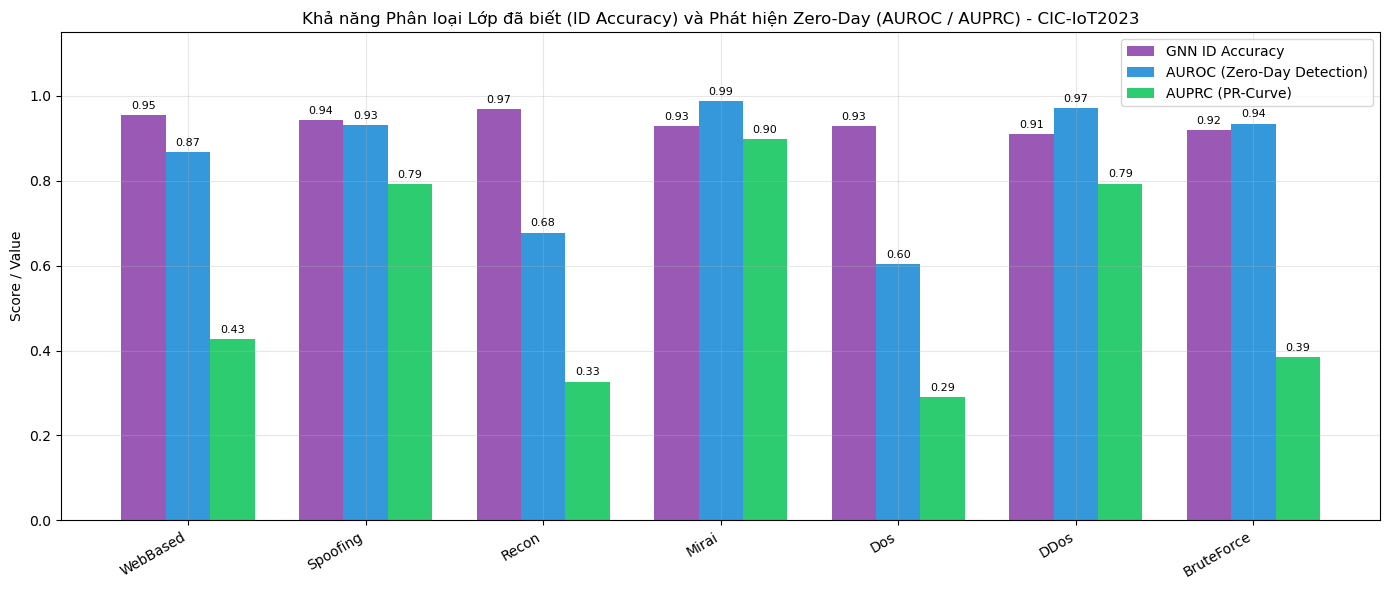

In [5]:
# BƯỚC 5: BÁO CÁO CHI TIẾT VÀ VẼ BIỂU ĐỒ SO SÁNH CÁC FOLDS (LƯU DRIVE)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("KẾT QUẢ TỔNG HỢP LEAVE-ONE-OUT ZERO-DAY (OOD) DETECTION")
print("-" * 85)
print(f"{'Attack Class (Zero-Day)':<25} | {'GNN ID Acc':^12} | {'AUROC':^10} | {'AUPRC':^10} | {'FPR@95TPR':^10}")
print("-" * 80)

id_accs, aurocs, auprcs, fpr95s = [], [], [], []
for name, metrics in loop_metrics.items():
    print(f"{name:<25} | {metrics['id_acc']:^12.4f} | {metrics['auroc']:^10.4f} | {metrics['auprc']:^10.4f} | {metrics['fpr95']:^10.4f}")
    id_accs.append(metrics['id_acc'])
    aurocs.append(metrics['auroc'])
    auprcs.append(metrics['auprc'])
    fpr95s.append(metrics['fpr95'])

print("-" * 80)
print(f"{'TRUNG BÌNH CỘNG (AVERAGE)':<25} | {np.mean(id_accs):^12.4f} | {np.mean(aurocs):^10.4f} | {np.mean(auprcs):^10.4f} | {np.mean(fpr95s):^10.4f}")
print("=" * 85)

# Xuất file báo cáo số liệu CSV về Google Drive
df_report = pd.DataFrame.from_dict(loop_metrics, orient='index')
df_report.loc['AVERAGE'] = [np.mean(aurocs), np.mean(auprcs), np.mean(fpr95s), np.mean(id_accs)]
report_path = '/storage/congnc/GNN4ID/data/loo_metrics_report.csv'
df_report.to_csv(report_path)
print(f"\n[OK] Đã xuất file báo cáo số liệu CSV về Google Drive thành công tại:\n  {report_path}")

# Vẽ biểu đồ so sánh
classes = list(loop_metrics.keys())
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width, [loop_metrics[c]['id_acc'] for c in classes], width, label='GNN ID Accuracy', color='#9b59b6')
rects2 = ax.bar(x, [loop_metrics[c]['auroc'] for c in classes], width, label='AUROC (Zero-Day Detection)', color='#3498db')
rects3 = ax.bar(x + width, [loop_metrics[c]['auprc'] for c in classes], width, label='AUPRC (PR-Curve)', color='#2ecc71')

ax.set_ylabel('Score / Value')
ax.set_title('Khả năng Phân loại Lớp đã biết (ID Accuracy) và Phát hiện Zero-Day (AUROC / AUPRC) - CIC-IoT2023')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

KẾT QUẢ LẦN TRAIN TRƯỚC (không có chuẩn hóa L2 ở embedding vector):
| Lớp Tấn Công bị ẩn (Zero-Day)    | Số mẫu Test ID | Số mẫu Test OOD |    GNN ID Acc    |      AUROC      |      AUPRC      |    FPR@95TPR    |
| :------------------------------------ | :--------------: | :---------------: | :--------------: | :--------------: | :--------------: | :--------------: |
| **WebBased** (1)                |      12,467      |       1,090       |      0.9726      |      0.8365      |      0.2485      |      0.3420      |
| **Spoofing** (2)                |      11,557      |       2,000       |      0.9574      |      0.8895      |      0.6592      |      0.2279      |
| **Recon** (3)                   |      11,557      |       2,000       |      0.9720      |      0.7323      |      0.3743      |      0.6300      |
| **Mirai** (4)                   |      11,557      |       2,000       |      0.9454      |      0.9908      |      0.9224      |      0.0114      |
| **Dos** (5)                     |      11,557      |       2,000       |      0.9343      |      0.5843      |      0.2832      |      0.5314      |
| **DDos** (6)                    |      11,557      |       2,000       |      0.9337      |      0.9967      |      0.9626      |      0.0026      |
| **BruteForce** (7)              |      13,090      |        467        |      0.9455      |      0.9290      |      0.3322      |      0.2499      |
| **TRUNG BÌNH CỘNG (AVERAGE)** | **11,906** |  **1,651**  | **0.9516** | **0.8513** | **0.5404** | **0.2850** |

In [ ]:
# =========================================================================
# BƯỚC 6: TRỰC QUAN HÓA KHÔNG GIAN EMBEDDING (t-SNE) CHO 7 FOLDS
# =========================================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Subset

SAVE_DIR = '/storage/congnc/GNN4ID/data/saved_models_loo'
VIZ_DIR  = '/storage/congnc/GNN4ID/data/viz_tsne'
os.makedirs(VIZ_DIR, exist_ok=True)

# Bảng màu cho 8 lớp (0=Benign, 1-7=Attacks)
CLASS_NAMES = {0:'Benign', 1:'WebBased', 2:'Spoofing', 3:'Recon',
               4:'Mirai',  5:'Dos',      6:'DDos',     7:'BruteForce'}
CLASS_COLORS = {
    0: '#2ecc71',  # Xanh lá - Benign
    1: '#3498db',  # Xanh dương - WebBased
    2: '#9b59b6',  # Tím - Spoofing
    3: '#f39c12',  # Cam - Recon
    4: '#1abc9c',  # Ngọc lam - Mirai
    5: '#e74c3c',  # Đỏ - Dos
    6: '#e67e22',  # Cam đậm - DDos
    7: '#34495e',  # Xám đen - BruteForce
}
OOD_COLOR = '#ff0000'  # Đỏ cho Zero-Day

ATTACK_CLASSES = {1:'WebBased', 2:'Spoofing', 3:'Recon',  4:'Mirai', 5:'Dos', 6:'DDos', 7:'BruteForce'}

for hidden_class, name in ATTACK_CLASSES.items():
    print(f"\n{'='*60}")
    print(f"  Đang vẽ t-SNE cho Fold: Ẩn '{name}' (Label {hidden_class})")
    print(f"{'='*60}")

    # --- 1. Load model đã lưu ---
    model_path = os.path.join(SAVE_DIR, f'model_loo_fold_{name}.pth')
    if not os.path.exists(model_path):
        print(f"  [SKIP] Không tìm thấy model tại {model_path}")
        continue

    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)
    model.load_state_dict(torch.load(model_path, weights_only=False))
    model.eval()

    # --- 2. Đăng ký hook trích xuất embedding ---
    emb_store = {}
    def get_act(n):
        def hook(mod, inp, out):
            emb_store[n] = inp[0].detach()
        return hook
    hook_h = model.classifier.register_forward_hook(get_act('emb'))

    # --- 3. Trích xuất embedding cho tập Test ID (giữ nhãn GỐC 0-7) ---
    test_id_idx = [i for i, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx = [i for i, l in enumerate(test_labels) if l == hidden_class]

    # Lấy mẫu tối đa 1500 mẫu ID và toàn bộ OOD để t-SNE chạy nhanh
    np.random.seed(42)
    if len(test_id_idx) > 1500:
        test_id_idx_sampled = np.random.choice(test_id_idx, 1500, replace=False).tolist()
    else:
        test_id_idx_sampled = test_id_idx

    if len(test_ood_idx) > 1000:
        test_ood_idx_sampled = np.random.choice(test_ood_idx, 1000, replace=False).tolist()
    else:
        test_ood_idx_sampled = test_ood_idx

    # Trích embedding cho ID (dùng Subset, không remap nhãn)
    id_subset = Subset(test_dataset_full, test_id_idx_sampled)
    id_loader_viz = DataLoader(id_subset, batch_size=128, shuffle=False, num_workers=2)

    all_embs_id = []
    all_labels_id = []
    with torch.no_grad():
        for batch in id_loader_viz:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            all_embs_id.append(emb_store['emb'].cpu().numpy())
            all_labels_id.append(batch.y.cpu().numpy())
    all_embs_id = np.vstack(all_embs_id)
    all_labels_id = np.concatenate(all_labels_id)

    # Trích embedding cho OOD
    ood_subset = Subset(test_dataset_full, test_ood_idx_sampled)
    ood_loader_viz = DataLoader(ood_subset, batch_size=128, shuffle=False, num_workers=2)

    all_embs_ood = []
    with torch.no_grad():
        for batch in ood_loader_viz:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            all_embs_ood.append(emb_store['emb'].cpu().numpy())
    all_embs_ood = np.vstack(all_embs_ood)

    hook_h.remove()

    # --- 4. Chạy t-SNE trên toàn bộ (ID + OOD) ---
    print(f"  Đang chạy t-SNE trên {len(all_embs_id)} mẫu ID + {len(all_embs_ood)} mẫu OOD...")
    combined_embs = np.vstack([all_embs_id, all_embs_ood])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto', init='pca')
    coords_2d = tsne.fit_transform(combined_embs)

    id_coords = coords_2d[:len(all_embs_id)]
    ood_coords = coords_2d[len(all_embs_id):]

    # --- 5. Vẽ biểu đồ ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Vẽ các cụm ID (mỗi lớp một màu)
    id_classes_present = sorted(set(all_labels_id.tolist()))
    for c in id_classes_present:
        mask = (all_labels_id == c)
        ax.scatter(id_coords[mask, 0], id_coords[mask, 1],
                   c=CLASS_COLORS.get(c, '#cccccc'), label=CLASS_NAMES.get(c, f'Class {c}'),
                   s=15, alpha=0.5, edgecolors='none')

    # Vẽ cụm OOD (Zero-Day) nổi bật nhất
    ax.scatter(ood_coords[:, 0], ood_coords[:, 1],
               c=OOD_COLOR, label=f'⚡ Zero-Day: {name}',
               s=40, alpha=0.85, edgecolors='black', linewidths=0.5, marker='X', zorder=10)

    ax.set_title(f"t-SNE Embedding — Fold: Ẩn '{name}' làm Zero-Day\n"
                 f"(ID classes = {len(id_classes_present)}, OOD = {len(all_embs_ood)} mẫu)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.legend(loc='best', fontsize=8, markerscale=1.5, framealpha=0.8)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    save_path = os.path.join(VIZ_DIR, f'tsne_fold_{name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [OK] Đã lưu hình tại: {save_path}")

print(f"\n{'-'*60}")
print(f"  ĐÃ VẼ XONG 7 HÌNH t-SNE! Lưu tại: {VIZ_DIR}")

# TRAIN LẦN 10: PHÁT HIỆN ZERO-DAY (OOD) & ĐỐI NGHỊCH BẰNG GELD (Graph Embedding Latent Diffusion)

Ý tưởng cốt lõi (từ bài báo **NI-Diff**):
1. Các mô hình GNN (`HeteroGNN_Edge_CIC_OOD`) đã huấn luyện ở Train 9 được đóng băng trọng số (frozen).
2. Trích xuất **Graph Embedding 128 chiều** (phần đầu vào của lớp classifier) cho các mẫu sạch (In-distribution).
3. Huấn luyện **VAE tiềm ẩn (128 -> 16)** và **DDPM** khuếch tán trong không gian tiềm ẩn 16 chiều trên các vector nhúng sạch này.
4. Đánh giá phát hiện OOD bằng khoảng cách **KL-Divergence** giữa xác suất softmax của GNN gốc và GNN sau khi tái cấu trúc bằng **1-step Denoising**. Nếu $D_{KL} \ge T$, mẫu được phân loại là OOD.

In [ ]:
# =========================================================================
# BƯỚC 1: ĐỊNH NGHĨA KIẾN TRÚC GELD VAE VÀ LATENT DDPM (1D RESMLP NOISE PREDICTOR)
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
class GELD_VAE(nn.Module):
    def __init__(self, input_dim=128, latent_dim=16, hidden_dim=64):
        super(GELD_VAE, self).__init__()
        # Encoder
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_bn1 = nn.BatchNorm1d(hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.enc_bn2 = nn.BatchNorm1d(hidden_dim // 2)

        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim // 2)
        self.dec_bn1 = nn.BatchNorm1d(hidden_dim // 2)
        self.dec_fc2 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.dec_bn2 = nn.BatchNorm1d(hidden_dim)
        self.dec_fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.leaky_relu(self.enc_bn1(self.enc_fc1(x)), 0.2)
        h = F.leaky_relu(self.enc_bn2(self.enc_fc2(h)), 0.2)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.leaky_relu(self.dec_bn1(self.dec_fc1(z)), 0.2)
        h = F.leaky_relu(self.dec_bn2(self.dec_fc2(h)), 0.2)
        return self.dec_fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim=32):
        super(TimeEmbedding, self).__init__()
        self.emb_dim = emb_dim
        self.fc1 = nn.Linear(emb_dim, emb_dim)
        self.fc2 = nn.Linear(emb_dim, emb_dim)

    def forward(self, t):
        if t.ndim == 1:
            t = t.unsqueeze(-1)
        half_dim = self.emb_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        emb = F.silu(self.fc1(emb))
        emb = self.fc2(emb)
        return emb
class ResBlock1D(nn.Module):
    def __init__(self, channels, time_dim, groups=4):
        super(ResBlock1D, self).__init__()
        self.fc1 = nn.Linear(channels, channels)
        self.gn1 = nn.GroupNorm(groups, channels)
        self.time_proj = nn.Linear(time_dim, channels)
        self.fc2 = nn.Linear(channels, channels)
        self.gn2 = nn.GroupNorm(groups, channels)

    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.fc1(x)))
        t_proj = self.time_proj(t_emb)
        h = h + t_proj
        h = F.silu(self.gn2(self.fc2(h)))
        return x + h
class DenoisingMLP(nn.Module):
    def __init__(self, latent_dim=16, hidden_dim=64, time_dim=32):
        super(DenoisingMLP, self).__init__()
        self.time_embed = TimeEmbedding(time_dim)
        self.in_proj = nn.Linear(latent_dim, hidden_dim)
        self.res1 = ResBlock1D(hidden_dim, time_dim, groups=4)
        self.res2 = ResBlock1D(hidden_dim, time_dim, groups=4)
        self.out_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z, t):
        t_emb = self.time_embed(t)
        h = self.in_proj(z)
        h = self.res1(h, t_emb)
        h = self.res2(h, t_emb)
        return self.out_proj(h)
class LatentDDPM(nn.Module):
    def __init__(self, model, latent_dim=16, beta_start=1e-4, beta_end=0.02, num_steps=1000):
        super(LatentDDPM, self).__init__()
        self.model = model
        self.latent_dim = latent_dim
        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)

        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod))

        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.register_buffer("posterior_variance", posterior_variance)

        posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)
        self.register_buffer("posterior_mean_coef1", posterior_mean_coef1)
        self.register_buffer("posterior_mean_coef2", posterior_mean_coef2)

    def q_sample(self, z_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(z_0)
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return sqrt_alphas_cumprod_t * z_0 + sqrt_one_minus_alphas_cumprod_t * noise

    def p_losses(self, z_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(z_0)
        z_t = self.q_sample(z_0=z_0, t=t, noise=noise)
        predicted_noise = self.model(z_t, t)
        return F.mse_loss(noise, predicted_noise)

    @torch.no_grad()
    def reconstruct_one_step(self, z_t, t):
        predicted_noise = self.model(z_t, t)
        sqrt_recip_alphas_cumprod_t = (1.0 / self.sqrt_alphas_cumprod[t]).unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        z_0_est = sqrt_recip_alphas_cumprod_t * (z_t - sqrt_one_minus_alphas_cumprod_t * predicted_noise)
        z_0_est = torch.clamp(z_0_est, min=-5.0, max=5.0)

        coef1 = self.posterior_mean_coef1[t].unsqueeze(-1)
        coef2 = self.posterior_mean_coef2[t].unsqueeze(-1)
        posterior_mean = coef1 * z_0_est + coef2 * z_t

        posterior_variance_t = self.posterior_variance[t].unsqueeze(-1)
        nonzero_mask = (t > 0).float().unsqueeze(-1)
        noise = torch.randn_like(z_t)
        return posterior_mean + nonzero_mask * torch.sqrt(posterior_variance_t) * noise
print("[OK] Đã khai báo thành công kiến trúc VAE và DDPM trong không gian tiềm ẩn!")


In [ ]:
# =========================================================================
# BƯỚC 2: HÀM TRÍCH XUẤT EMBEDDINGS VÀ HUẤN LUYỆN VAE + DDPM
# =========================================================================

def extract_embeddings_and_labels(loader, model, device):
    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook

    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))
    model.eval()

    all_embs = []
    all_ys = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].clone()
            all_embs.append(batch_embs)
            all_ys.append(batch.y.clone())

    hook_handle.remove()
    return torch.cat(all_embs, dim=0), torch.cat(all_ys, dim=0)

def train_vae(vae, embeddings, epochs=80, lr=1e-3, batch_size=128, device='cpu'):
    vae.to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(embeddings)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        vae.train()
        total_loss = 0
        total_mse = 0
        total_kld = 0
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = vae(batch_x)

            mse = F.mse_loss(x_recon, batch_x)
            kld = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = mse + 1e-5 * kld

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_x)
            total_mse += mse.item() * len(batch_x)
            total_kld += kld.item() * len(batch_x)

        if epoch % 20 == 0 or epoch == epochs:
            avg_loss = total_loss / len(embeddings)
            avg_mse = total_mse / len(embeddings)
            avg_kld = total_kld / len(embeddings)
            print(f"    VAE Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.6f} (MSE: {avg_mse:.6f}, KLD: {avg_kld:.6f})")

def train_ddpm(ddpm, latent_zs, epochs=120, lr=1e-4, batch_size=128, device='cpu'):
    ddpm.to(device)
    optimizer = torch.optim.Adam(ddpm.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(latent_zs)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        ddpm.train()
        total_loss = 0
        for (batch_z,) in loader:
            batch_z = batch_z.to(device)
            optimizer.zero_grad()
            t = torch.randint(0, ddpm.num_steps, (len(batch_z),), device=device)
            loss = ddpm.p_losses(batch_z, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_z)

        if epoch % 30 == 0 or epoch == epochs:
            avg_loss = total_loss / len(latent_zs)
            print(f"    DDPM Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.6f}")

In [ ]:
# =========================================================================
# BƯỚC 3: HÀM TÍNH KHOẢNG CÁCH KLD OOD Dựa Tên TÁI CẤU TRÚC KHUẾCH TÁN
# =========================================================================

def compute_kld_scores(loader, model, vae, ddpm, device, t_step=50):
    vae.eval()
    ddpm.eval()
    model.eval()

    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook

    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))

    scores = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            y_prob = torch.exp(pred) # Shape: [Batch, num_classes]

            h = graph_embs_dict['emb'] # Shape: [Batch, 128]
            mu, logvar = vae.encode(h)
            z_0 = mu

            t_tensor = torch.full((len(h),), t_step, dtype=torch.long, device=device)
            z_t = ddpm.q_sample(z_0, t_tensor)
            z_prev = ddpm.reconstruct_one_step(z_t, t_tensor)
            h_recon = vae.decode(z_prev)

            pred_recon = model.classifier(h_recon)
            y_recon_prob = F.softmax(pred_recon, dim=1)

            eps = 1e-10
            kl_div = torch.sum(y_prob * (torch.log(y_prob + eps) - torch.log(y_recon_prob + eps)), dim=1)
            scores.extend(kl_div.cpu().numpy().tolist())

    hook_handle.remove()
    return np.array(scores)

print("[OK] Khởi tạo hàm tính toán độ chênh lệch phân phối KLD thành công!")

In [ ]:
# =========================================================================
# BƯỚC 4: CHẠY KIỂM THỬ GELD-OOD TRÊN 7 FOLDS VÀ SO SÁNH VỚI MAHALANOBIS
# =========================================================================
import os
import numpy as np
import torch
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve

# Cấu hình fallback nếu chạy trực tiếp Train 10 (bỏ qua Train 9)
if 'ATTACK_CLASSES' not in globals():
    ATTACK_CLASSES = {
        1: 'WebBased',
        2: 'Spoofing',
        3: 'Recon',
        4: 'Mirai',
        5: 'Dos',
        6: 'DDos',
        7: 'BruteForce'
    }
if 'USE_SUBSET' not in globals():
    USE_SUBSET = True
if 'SUBSET_SIZE_PER_CLASS' not in globals():
    SUBSET_SIZE_PER_CLASS = 5000
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 128
if 'loop_metrics' not in globals():
    loop_metrics = {}
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loop_metrics_geld = {}
T_STEP_EVAL = 50 # Số bước nhiễu sử dụng để ngụy trang/khử nhiễu

for hidden_class, name in ATTACK_CLASSES.items():
    print("=" * 75)
    print(f"GELD-OOD EVALUATION: Ẩn lớp Tấn công '{name}' (Label {hidden_class})")
    print("=" * 75)

    # 1. Khôi phục dataset phân chia giống hệt Train 9
    train_id_idx_all = [idx for idx, l in enumerate(train_labels) if l != hidden_class]
    test_id_idx_all  = [idx for idx, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx     = [idx for idx, l in enumerate(test_labels) if l == hidden_class]

    if USE_SUBSET:
        np.random.seed(42)
        train_id_idx = []
        train_labels_np = np.array(train_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(train_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(SUBSET_SIZE_PER_CLASS, len(class_indices)), replace=False)
                train_id_idx.extend(sampled.tolist())

        test_id_idx = []
        test_labels_np = np.array(test_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(test_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(2000, len(class_indices)), replace=False)
                test_id_idx.extend(sampled.tolist())
    else:
        train_id_idx = train_id_idx_all
        test_id_idx  = test_id_idx_all

    train_mapped = LabelMappingDataset(train_dataset_full, train_id_idx, hidden_class)
    test_id_mapped = LabelMappingDataset(test_dataset_full, test_id_idx, hidden_class)
    ood_subset = Subset(test_dataset_full, test_ood_idx)

    train_loader = DataLoader(train_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_id_loader = DataLoader(test_id_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ood_loader = DataLoader(ood_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # 2. Khởi tạo và load GNN đã huấn luyện từ Train 9
    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)

    save_dir = '/storage/congnc/GNN4ID/data/saved_models_loo'
    model_save_path = os.path.join(save_dir, f'model_loo_fold_{name}.pth')
    if os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        print(f"  - [LOAD GNN] Đã load thành công checkpoint GNN cho fold '{name}'")
    else:
        print(f"  - [ERROR] Không tìm thấy checkpoint GNN tại {model_save_path}. Hãy chạy Train 9 trước.")
        continue

    # 3. Trích xuất embeddings sạch của tập train để huấn luyện VAE + DDPM
    print("  - Đang trích xuất vector nhúng Graph Embeddings sạch của tập Train...")
    train_embs, _ = extract_embeddings_and_labels(train_loader, model, device)
    print(f"    Trích xuất xong! Kích thước embeddings: {train_embs.shape}")

    # 4. Huấn luyện VAE tiềm ẩn
    print("  - Đang huấn luyện VAE trên vector nhúng sạch...")
    vae = GELD_VAE(input_dim=128, latent_dim=16, hidden_dim=64)
    train_vae(vae, train_embs, epochs=80, lr=1e-3, device=device)

    # 5. Huấn luyện DDPM tiềm ẩn
    print("  - Đang chiếu embeddings sang không gian latent z và train DDPM...")
    vae.eval()
    with torch.no_grad():
        mu, _ = vae.encode(train_embs.to(device))
        latent_zs = mu.detach().cpu()

    mlp_denoise = DenoisingMLP(latent_dim=16, hidden_dim=64, time_dim=32)
    ddpm = LatentDDPM(mlp_denoise, latent_dim=16)
    train_ddpm(ddpm, latent_zs, epochs=120, lr=1e-4, device=device)

    # 6. Suy luận phát hiện OOD bằng KLD
    print(f"  - Đang chạy suy luận phát hiện OOD với KLD (t={T_STEP_EVAL})...")
    id_kld_scores = compute_kld_scores(test_id_loader, model, vae, ddpm, device, t_step=T_STEP_EVAL)
    ood_kld_scores = compute_kld_scores(ood_loader, model, vae, ddpm, device, t_step=T_STEP_EVAL)

    # 7. Tính toán các metric chất lượng
    y_true = np.concatenate([np.zeros(len(id_kld_scores)), np.ones(len(ood_kld_scores))])
    y_scores = np.concatenate([id_kld_scores, ood_kld_scores])

    auroc = roc_auc_score(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auprc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    # Lấy thông số đối chiếu Mahalanobis hiện tại của Train 9
    baseline_metrics = loop_metrics.get(name, {'auroc': 0.0, 'fpr95': 1.0})

    print(f"  -> KẾT QUẢ GELD-OOD FOLD '{name}':")
    print(f"     [GELD-OOD (Diffusion)]   AUROC = {auroc:.4f} | FPR95 = {fpr95:.4f}")
    print(f"     [Mahalanobis (Baseline)]  AUROC = {baseline_metrics['auroc']:.4f} | FPR95 = {baseline_metrics['fpr95']:.4f}")

    loop_metrics_geld[name] = {
        'auroc': auroc,
        'auprc': auprc,
        'fpr95': fpr95,
        'baseline_auroc': baseline_metrics['auroc'],
        'baseline_fpr95': baseline_metrics['fpr95']
    }

# 8. Báo cáo bảng đối chiếu tổng kết
print("\n" + "="*90)
print(f" BẢNG ĐỐI CHIẾU HIỆU NĂNG PHÁT HIỆN ZERO-DAY: MAHALANOBIS VS GELD (DIFFUSION) ")
print("="*90)
print(f"{'Fold (OOD Class)':<20} | {'Maha AUROC':<12} | {'GELD AUROC':<12} | {'Maha FPR95':<12} | {'GELD FPR95':<12}")
print("-"*90)
for name, m in loop_metrics_geld.items():
    print(f"{name:<20} | {m['baseline_auroc']:<12.4f} | {m['auroc']:<12.4f} | {m['baseline_fpr95']:<12.4f} | {m['fpr95']:<12.4f}")
print("="*90)

In [ ]:
# 9. Lưu kết quả đối chiếu về Google Drive
import pandas as pd
df_geld_report = pd.DataFrame.from_dict(loop_metrics_geld, orient='index')
report_csv_path = os.path.join(save_dir, 'geld_vs_mahalanobis_report.csv')
df_geld_report.to_csv(report_csv_path)
print(f"\n[OK] Báo cáo dạng CSV đã được lưu tại: {report_csv_path}")
report_txt_path = os.path.join(save_dir, 'geld_vs_mahalanobis_report.txt')
with open(report_txt_path, 'w', encoding='utf-8') as f:
    f.write("="*90 + "\n")
    f.write(" BẢNG ĐỐI CHIẾU HIỆU NĂNG PHÁT HIỆN ZERO-DAY: MAHALANOBIS VS GELD (DIFFUSION) \n")
    f.write("="*90 + "\n")
    f.write(f"{'Fold (OOD Class)':<20} | {'Maha AUROC':<12} | {'GELD AUROC':<12} | {'Maha FPR95':<12} | {'GELD FPR95':<12}\n")
    f.write("-"*90 + "\n")
    for fold_n, m_vals in loop_metrics_geld.items():
        f.write(f"{fold_n:<20} | {m_vals['baseline_auroc']:<12.4f} | {m_vals['auroc']:<12.4f} | {m_vals['baseline_fpr95']:<12.4f} | {m_vals['fpr95']:<12.4f}\n")
    f.write("="*90 + "\n")
print(f"[OK] Báo cáo dạng text trực quan đã được lưu tại: {report_txt_path}")

# TRAIN 10.b: TABULAR DIFFUSION TRÊN DỮ LIỆU CSV GỐC (BỎ QUA GNN)

Phiên bản này áp dụng trực tiếp mô hình **Tabular DDPM** lên file CSV đã được làm sạch, bám sát kiến trúc của NI-Diff. Việc bỏ qua GNN giúp tránh mất mát thông tin khi nén thành Graph Embedding 128 chiều.

**Luồng thực thi:**
1. **Preprocess:** Chuẩn hóa Z-Score toàn bộ Features số thực của file CSV.
2. **Kiến trúc:** Xây dựng Score Network dạng Res-MLP mạnh mẽ thay vì MLP tuyến tính đơn giản.
3. **Đánh giá:** Tính toán điểm OOD dựa trên **Reconstruction Error (MSE)** trên không gian nguyên bản, thay vì thông qua softmax KLD.

In [ ]:
# =========================================================================
# BƯỚC 1: TIỀN XỬ LÝ DỮ LIỆU DẠNG BẢNG (TABULAR PREPROCESSING)
# =========================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Đường dẫn file CSV sạch (từ Cell 74)
CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'

# Các cột bỏ qua (không dùng làm features)
drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'mapped_label']

def load_and_preprocess_tabular(train_path, test_path):
    print("Đang nạp dữ liệu CSV...")
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    # Chuẩn hóa tên cột để dễ xử lý (chuyển về chữ thường)
    df_train.columns = [c.strip() for c in df_train.columns]
    df_test.columns = [c.strip() for c in df_test.columns]

    # Lấy nhãn
    label_col = 'label' if 'label' in df_train.columns else df_train.columns[-1]
    y_train = df_train[label_col].values
    y_test = df_test[label_col].values

    # Lấy Features
    actual_drop_cols = [c for c in df_train.columns if any(d.lower() == c.lower() for d in drop_cols)]
    X_train_raw = df_train.drop(columns=actual_drop_cols + [label_col], errors='ignore')
    X_test_raw = df_test.drop(columns=actual_drop_cols + [label_col], errors='ignore')

    # Đảm bảo các cột map nhau
    common_cols = [c for c in X_train_raw.columns if c in X_test_raw.columns]
    X_train_raw = X_train_raw[common_cols]
    X_test_raw = X_test_raw[common_cols]

    # Thay thế NaN / Inf
    # Lọc chỉ lấy các cột dữ liệu dạng số (tránh lỗi danh sách mảng byte)
    numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
    X_train_raw = X_train_raw[numeric_cols]
    X_test_raw = X_test_raw[numeric_cols]

    X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

    print(f"Số lượng features Tabular (Numeric): {len(numeric_cols)}")

    print("Đang chuẩn hóa Z-Score StandardScaler...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_train, y_train, X_test, y_test

if 'X_train_tab' not in globals():
    try:
        X_train_tab, y_train_tab, X_test_tab, y_test_tab = load_and_preprocess_tabular(CLEANED_TRAIN, CLEANED_TEST)
        print(f"[OK] Hoàn tất tiền xử lý! X_train_tab shape: {X_train_tab.shape}")
    except Exception as e:
        print(f"[WARNING] Lỗi khi load CSV: {e}. Vui lòng kiểm tra file CSV trên Colab.")

In [ ]:
# =========================================================================
# BƯỚC 2: KIẾN TRÚC TABULAR DDPM VÀ RES-MLP SCORE NETWORK
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TimeEmbeddingTabular(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.emb_dim = emb_dim
        self.fc1 = nn.Linear(emb_dim, emb_dim)
        self.fc2 = nn.Linear(emb_dim, emb_dim)

    def forward(self, t):
        if t.ndim == 1:
            t = t.unsqueeze(-1)
        half_dim = self.emb_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        emb = F.silu(self.fc1(emb))
        emb = self.fc2(emb)
        return emb

class TabularResBlock(nn.Module):
    def __init__(self, channels, time_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels)
        self.bn1 = nn.BatchNorm1d(channels)
        self.time_proj = nn.Linear(time_dim, channels)
        self.fc2 = nn.Linear(channels, channels)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, t_emb):
        h = F.silu(self.bn1(self.fc1(x)))
        t_proj = self.time_proj(t_emb)
        h = h + t_proj
        h = F.silu(self.bn2(self.fc2(h)))
        h = self.dropout(h)
        return x + h

class TabularScoreNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, time_dim=128, num_blocks=4):
        super().__init__()
        self.time_embed = TimeEmbeddingTabular(time_dim)
        self.in_proj = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            TabularResBlock(hidden_dim, time_dim) for _ in range(num_blocks)
        ])

        self.out_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h, t_emb)
        return self.out_proj(h)

class TabularDDPM(nn.Module):
    def __init__(self, model, num_steps=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.model = model
        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod))

        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        self.register_buffer("posterior_variance", betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod))
        self.register_buffer("posterior_mean_coef1", betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod))
        self.register_buffer("posterior_mean_coef2", (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod))

    def q_sample(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

    def p_losses(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.q_sample(x_0, t, noise)
        predicted_noise = self.model(x_t, t)
        return F.mse_loss(noise, predicted_noise)

    @torch.no_grad()
    def denoise_step(self, x_t, t):
        predicted_noise = self.model(x_t, t)
        sqrt_recip_alphas_cumprod_t = (1.0 / self.sqrt_alphas_cumprod[t]).unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)

        x_0_est = sqrt_recip_alphas_cumprod_t * (x_t - sqrt_one_minus_alphas_cumprod_t * predicted_noise)

        coef1 = self.posterior_mean_coef1[t].unsqueeze(-1)
        coef2 = self.posterior_mean_coef2[t].unsqueeze(-1)
        posterior_mean = coef1 * x_0_est + coef2 * x_t

        noise = torch.randn_like(x_t)
        nonzero_mask = (t > 0).float().unsqueeze(-1)
        return posterior_mean + nonzero_mask * torch.sqrt(self.posterior_variance[t].unsqueeze(-1)) * noise

print("[OK] Tabular DDPM Khởi tạo thành công!")

In [ ]:
# =========================================================================
# BƯỚC 3: HÀM HUẤN LUYỆN DDPM VÀ TÍNH LỖI TÁI CẤU TRÚC (RECONSTRUCTION MSE)
# =========================================================================
from torch.utils.data import DataLoader, TensorDataset

def train_tabular_ddpm(ddpm, X_train_tensor, epochs=50, lr=1e-3, batch_size=256, device='cuda'):
    ddpm.to(device)
    optimizer = torch.optim.Adam(ddpm.parameters(), lr=lr)
    dataset = TensorDataset(X_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        ddpm.train()
        total_loss = 0
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            t = torch.randint(0, ddpm.num_steps, (len(batch_x),), device=device)
            loss = ddpm.p_losses(batch_x, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_x)

        if epoch % 10 == 0 or epoch == epochs:
            print(f"    Epoch {epoch:3d}/{epochs} | Loss DDPM: {total_loss / len(X_train_tensor):.5f}")

@torch.no_grad()
def compute_reconstruction_error(ddpm, X_tensor, t_step=100, batch_size=256, device='cuda'):
    ddpm.eval()
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    mse_scores = []

    for (batch_x,) in loader:
        batch_x = batch_x.to(device)

        t_tensor = torch.full((len(batch_x),), t_step, dtype=torch.long, device=device)
        x_t = ddpm.q_sample(batch_x, t_tensor)

        x_curr = x_t
        for i in reversed(range(0, t_step + 1)):
            t_curr = torch.full((len(batch_x),), i, dtype=torch.long, device=device)
            x_curr = ddpm.denoise_step(x_curr, t_curr)

        error = torch.mean((batch_x - x_curr)**2, dim=1)
        mse_scores.extend(error.cpu().numpy().tolist())

    return np.array(mse_scores)
print("[OK] Đã sẵn sàng các hàm huấn luyện và đánh giá Tabular Diffusion.")

In [ ]:
# =========================================================================
# BƯỚC 4: CHẠY TRAIN 10.b (TABULAR DIFFUSION) TRÊN 7 FOLDS OOD
# =========================================================================
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score

if 'ATTACK_CLASSES' not in globals():
    ATTACK_CLASSES = {1:'WebBased', 2:'Spoofing', 3:'Recon', 4:'Mirai', 5:'Dos', 6:'DDos', 7:'BruteForce'}

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loop_metrics_tabular = {}
T_STEP_EVAL_TAB = 30  # Số bước nhiễu để đánh giá (nếu chạy quá lâu có thể giảm xuống 20)

if 'X_train_tab' in globals():
    for hidden_class, name in ATTACK_CLASSES.items():
        print("=" * 80)
        print(f"TABULAR DIFFUSION OOD: Ẩn lớp Tấn công '{name}' (Label {hidden_class})")
        print("=" * 80)

        train_id_mask = (y_train_tab != hidden_class)
        test_id_mask = (y_test_tab != hidden_class)
        test_ood_mask = (y_test_tab == hidden_class)

        X_train_fold = X_train_tab[train_id_mask]
        X_test_id = X_test_tab[test_id_mask]
        X_test_ood = X_test_tab[test_ood_mask]

        SUBSET_SIZE = 40000
        if len(X_train_fold) > SUBSET_SIZE:
            np.random.seed(42)
            idx = np.random.choice(len(X_train_fold), SUBSET_SIZE, replace=False)
            X_train_fold = X_train_fold[idx]

        if len(X_test_id) > 10000:
            np.random.seed(42)
            X_test_id = X_test_id[np.random.choice(len(X_test_id), 10000, replace=False)]
        if len(X_test_ood) > 10000:
            np.random.seed(42)
            X_test_ood = X_test_ood[np.random.choice(len(X_test_ood), 10000, replace=False)]

        X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
        X_test_id_tensor = torch.tensor(X_test_id, dtype=torch.float32)
        X_test_ood_tensor = torch.tensor(X_test_ood, dtype=torch.float32)

        input_dim = X_train_tensor.shape[1]
        score_net = TabularScoreNetwork(input_dim=input_dim, hidden_dim=256, num_blocks=3)
        ddpm = TabularDDPM(score_net, num_steps=100)

        print("  - Đang huấn luyện Tabular DDPM trên dữ liệu sạch...")
        train_tabular_ddpm(ddpm, X_train_tensor, epochs=30, batch_size=256, device=device)

        print(f"  - Đang suy luận Reconstruction Error (T={T_STEP_EVAL_TAB})...")
        id_errors = compute_reconstruction_error(ddpm, X_test_id_tensor, t_step=T_STEP_EVAL_TAB, device=device)
        ood_errors = compute_reconstruction_error(ddpm, X_test_ood_tensor, t_step=T_STEP_EVAL_TAB, device=device)

        y_true = np.concatenate([np.zeros(len(id_errors)), np.ones(len(ood_errors))])
        y_scores = np.concatenate([id_errors, ood_errors])

        auroc = roc_auc_score(y_true, y_scores)
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        fpr95 = fpr[np.argmax(tpr >= 0.95)]

        baseline_metrics = loop_metrics.get(name, {'auroc': 0.0, 'fpr95': 1.0}) if 'loop_metrics' in globals() else {'auroc': 0.0, 'fpr95': 1.0}

        print(f"  -> KẾT QUẢ TABULAR DIFFUSION FOLD '{name}':")
        print(f"     [Tabular DDPM]  AUROC = {auroc:.4f} | FPR95 = {fpr95:.4f}")
        print(f"     [Maha Baseline] AUROC = {baseline_metrics['auroc']:.4f} | FPR95 = {baseline_metrics['fpr95']:.4f}")

        loop_metrics_tabular[name] = {
            'auroc': auroc,
            'fpr95': fpr95,
            'baseline_auroc': baseline_metrics['auroc'],
            'baseline_fpr95': baseline_metrics['fpr95']
        }

    print("\n" + "="*80)
    print(" BẢNG TỔNG KẾT: MAHALANOBIS (GNN) VS TABULAR DIFFUSION (CSV GỐC)")
    print("="*80)
    print(f"{'Fold (Zero-Day)':<20} | {'Maha AUROC':<12} | {'Tabular AUROC':<15} | {'Maha FPR95':<12} | {'Tabular FPR95':<15}")
    print("-"*80)
    for name, m in loop_metrics_tabular.items():
        print(f"{name:<20} | {m['baseline_auroc']:<12.4f} | {m['auroc']:<15.4f} | {m['baseline_fpr95']:<12.4f} | {m['fpr95']:<15.4f}")
    print("="*80)
else:
    print("[ERROR] Không tìm thấy dữ liệu X_train_tab. Hãy chạy Cell Bước 1 của Train 10.b trước.")

## BƯỚC 11: MỞ RỘNG OOD POST-HOC (Energy, MLS, ViM, Mahalanobis)
Trong bước này, chúng ta tiến hành tái cấu trúc mã nguồn đánh giá OOD: đóng gói mỗi thuật toán (GNN Mahalanobis, MLS, Energy Score, ViM) thành các Class riêng biệt nằm ở các Cell độc lập, sau đó chạy đánh giá chung và kẻ bảng so sánh theo các metrics từ bài báo NI-Diff.

**Các thuật toán được đóng gói bao gồm:**
1. **GNN (Mahalanobis)**: Mô hình khoảng cách Mahalanobis trên tầng nhúng GNN (phương pháp từ Train 9).
2. **MLS (Maximum Logit Score)**: Đo độ tin cậy bằng Logit tối đa.
3. **Energy Score**: Sử dụng năng lượng tự do Helmholtz.
4. **ViM (Virtual-logit Matching)**: Chiếu đặc trưng lên Không gian bù (Null Space / Residual Space) thu từ phân tích hiệp phương sai và hiệu chỉnh với logits theo code gốc của tác giả.

In [ ]:
# CLASS 1: MAHALANOBIS DETECTOR (GNN BASELINE)
import torch
import numpy as np

class MahalanobisDetector:
    def __init__(self, model):
        self.model = model
        self.features = None
        self.class_means = {}
        self.inv_cov = None

    def _hook(self, module, input, output):
        # Trích xuất đặc trưng đầu vào của bộ phân loại (concatenated graph embedding)
        self.features = input[0].detach().cpu().numpy()

    def fit(self, train_loader, device):
        self.model.eval()
        # Đăng ký hook cho toàn bộ classifier để lấy đầu vào
        hook_handle = self.model.classifier.register_forward_hook(self._hook)

        class_embs = {c: [] for c in range(7)}
        with torch.no_grad():
            for batch in train_loader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)

                # Chuẩn hóa L2
                batch_embs = self.features
                norm = np.linalg.norm(batch_embs, axis=-1, keepdims=True)
                batch_embs = batch_embs / (norm + 1e-10)

                batch_ys = batch.y.cpu().numpy()
                for c in range(7):
                    mask = (batch_ys == c)
                    if mask.sum() > 0:
                        class_embs[c].append(batch_embs[mask])

        hook_handle.remove()

        # Tính toán vector trung bình cho từng lớp (centroids)
        centered_embs = []
        for c in range(7):
            if len(class_embs[c]) > 0:
                stacked = np.vstack(class_embs[c])
                mu = np.mean(stacked, axis=0)
                self.class_means[c] = mu
                centered_embs.append(stacked - mu)

        # Tính toán ma trận hiệp phương sai chung
        all_centered = np.vstack(centered_embs)
        cov = np.cov(all_centered, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-4  # Regularization tránh suy biến
        self.inv_cov = np.linalg.inv(cov)
        print("-> Đã fit xong Mahalanobis Detector.")

    def predict(self, dataloader, device):
        self.model.eval()
        hook_handle = self.model.classifier.register_forward_hook(self._hook)

        all_scores = []
        with torch.no_grad():
            for batch in dataloader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)

                # Chuẩn hóa L2
                batch_embs = self.features
                norm = np.linalg.norm(batch_embs, axis=-1, keepdims=True)
                batch_embs = batch_embs / (norm + 1e-10)

                # Tính khoảng cách Mahalanobis nhỏ nhất tới các cụm lớp
                for emb in batch_embs:
                    dists = []
                    for c, mu in self.class_means.items():
                        diff = emb - mu
                        d = np.sqrt(np.dot(np.dot(diff, self.inv_cov), diff))
                        dists.append(d)
                    all_scores.append(np.min(dists))  # Khoảng cách nhỏ nhất là điểm OOD

        hook_handle.remove()
        return np.array(all_scores)

In [ ]:
# CLASS 2: MLS (MAXLOGIT) DETECTOR
import torch
import numpy as np

class MLSDetector:
    def __init__(self, model):
        self.model = model
        self.logits = None

    def _hook(self, module, input, output):
        # Trích xuất logits thô đầu ra của lớp tuyến tính cuối cùng
        self.logits = output.detach().cpu().numpy()

    def fit(self, train_loader, device):
        pass  # MLS không cần fit dữ liệu train

    def predict(self, dataloader, device):
        self.model.eval()
        # Đăng ký hook ở lớp Linear cuối cùng để lấy raw logits trước log_softmax
        hook_handle = self.model.classifier[-1].register_forward_hook(self._hook)

        all_scores = []
        with torch.no_grad():
            for batch in dataloader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)

                # Điểm bất thường MLS = - max(logits)
                scores = - np.max(self.logits, axis=1)
                all_scores.extend(scores.tolist())

        hook_handle.remove()
        return np.array(all_scores)

In [ ]:
# CLASS 3: ENERGY SCORE DETECTOR
import torch
import numpy as np
from scipy.special import logsumexp

class EnergyDetector:
    def __init__(self, model, T=1.0):
        self.model = model
        self.T = T
        self.logits = None

    def _hook(self, module, input, output):
        self.logits = output.detach().cpu().numpy()

    def fit(self, train_loader, device):
        pass  # Energy Score không cần fit dữ liệu train

    def predict(self, dataloader, device):
        self.model.eval()
        hook_handle = self.model.classifier[-1].register_forward_hook(self._hook)

        all_scores = []
        with torch.no_grad():
            for batch in dataloader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)

                # Điểm bất thường Energy = - T * logsumexp(logits / T)
                scores = - (self.T * logsumexp(self.logits / self.T, axis=1))
                all_scores.extend(scores.tolist())

        hook_handle.remove()
        return np.array(all_scores)

In [ ]:
# CLASS 4: VIM (VIRTUAL-LOGIT MATCHING) DETECTOR
import torch
import numpy as np
from numpy.linalg import pinv, norm
from scipy.special import logsumexp
from sklearn.covariance import EmpiricalCovariance

class ViMDetector:
    def __init__(self, model):
        self.model = model
        self.features = None
        self.logits = None
        self.u = None
        self.NS = None
        self.alpha = None

    def _hook(self, module, input, output):
        # Trích xuất đặc trưng kề cuối (input của lớp Linear cuối) và logits (output)
        self.features = input[0].detach().cpu().numpy()
        self.logits = output.detach().cpu().numpy()

    def fit(self, train_loader, device):
        self.model.eval()
        hook_handle = self.model.classifier[-1].register_forward_hook(self._hook)

        all_features = []
        all_logits = []
        with torch.no_grad():
            for batch in train_loader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
                all_features.append(self.features)
                all_logits.append(self.logits)

        hook_handle.remove()

        features_id = np.concatenate(all_features, axis=0)
        logits_id = np.concatenate(all_logits, axis=0)

        # Lấy trọng số w và bias b của lớp phân loại cuối cùng
        w = self.model.classifier[-1].weight.detach().cpu().numpy()
        b = self.model.classifier[-1].bias.detach().cpu().numpy()

        # 1. Tính toán điểm gốc mới u = -pinv(w) @ b (theo code của tác giả trong benchmark.py)
        self.u = -np.matmul(pinv(w), b)

        # 2. Dịch tâm đặc trưng huấn luyện
        X = features_id - self.u

        # 3. Tính không gian con bổ sung (Null Space) bằng phân tích hiệp phương sai mẫu
        ec = EmpiricalCovariance(assume_centered=True)
        ec.fit(X)
        eig_vals, eigen_vectors = np.linalg.eigh(ec.covariance_)

        # Sắp xếp các trị riêng và vectơ riêng theo thứ tự giảm dần
        idx = np.argsort(eig_vals)[::-1]
        eig_vals = eig_vals[idx]
        eigen_vectors = eigen_vectors[:, idx]

        # Lấy không gian con bổ sung NS ứng với các trị riêng bé hơn (bắt đầu từ DIM)
        DIM = features_id.shape[-1] // 2
        self.NS = np.ascontiguousarray(eigen_vectors[:, DIM:])

        # 4. Tính toán hệ số tỷ lệ alpha
        vlogit_id_train = norm(np.matmul(X, self.NS), axis=-1)
        self.alpha = logits_id.max(axis=-1).mean() / (vlogit_id_train.mean() + 1e-10)
        print("-> Đã fit xong ViM Detector chuẩn theo code tác giả.")

    def predict(self, dataloader, device):
        self.model.eval()
        hook_handle = self.model.classifier[-1].register_forward_hook(self._hook)

        all_scores = []
        with torch.no_grad():
            for batch in dataloader:
                batch = batch.to(device)
                _ = self.model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)

                # Dịch tâm và chiếu lên Null Space
                X = self.features - self.u
                vlogit = norm(np.matmul(X, self.NS), axis=-1) * self.alpha
                energy = logsumexp(self.logits, axis=-1)

                # Điểm bất thường = vlogit - energy
                scores = vlogit - energy
                all_scores.extend(scores.tolist())

        hook_handle.remove()
        return np.array(all_scores)

In [ ]:
# CÁC HÀM HỖ TRỢ ĐÁNH GIÁ (THEO CHUẨN NI-DIFF)
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, roc_curve

def evaluate_nidiff_metrics(scores_id, scores_ood):
    y_true = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))])
    y_scores = np.concatenate([scores_id, scores_ood]) # Nhận đầu vào là Anomaly Score (Càng cao càng OOD)

    # 1. AUROC
    auroc = roc_auc_score(y_true, y_scores)

    # 2. FPR95
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.where(tpr >= 0.95)[0][0]
    fpr95 = fpr[idx]

    # Tìm ngưỡng tối ưu cho F1 và Precision bằng chỉ số Youden's J
    J = tpr - fpr
    best_thresh = thresholds[np.argmax(J)]
    y_pred = (y_scores >= best_thresh).astype(int)

    # 3. F1 & Precision
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)

    return auroc, fpr95, f1, precision

In [ ]:
# VÒNG LẶP HUẤN LUYỆN / ĐÁNH GIÁ CHUNG TRÊN 7 FOLDS VÀ KẺ BẢNG SO SÁNH
import os
import sys
import glob
import gc
import shutil
import subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader

# =========================================================================
# 1. THIẾT LẬP MÔI TRƯỜNG & KHỞI TẠO ĐƯỜNG DẪN DỮ LIỆU
# =========================================================================
# (local: khong can mount Google Drive)

if not os.path.exists('/storage/congnc/GNN4ID'):
    print("Cloning GNN4ID...")
    subprocess.run(["git", "clone", "https://github.com/Yasir-ali-farrukh/GNN4ID.git", "/storage/congnc/GNN4ID"])
if '/storage/congnc/GNN4ID' not in sys.path:
    sys.path.insert(0, '/storage/congnc/GNN4ID')

from Utility.Functions import NIDSDataset

DRIVE_DATA_PATH = '/storage/congnc/GNN4ID/data'
CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def patched_load(*args, **kwargs):
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return torch._orig_load(*args, **kwargs)
    torch.load = patched_load

# Wrapper Dataset để lọc và map nhãn động
class LabelMappingDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, hidden_class):
        self.base_dataset = base_dataset
        self.indices = indices
        self.hidden_class = hidden_class
        self.old_to_new = {}
        new_label = 0
        for old_label in range(8):
            if old_label == hidden_class: continue
            self.old_to_new[old_label] = new_label
            new_label += 1
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        data = self.base_dataset[real_idx].clone()
        old_y = data.y.item()
        new_y = self.old_to_new.get(old_y, 0)
        data.y = torch.tensor([new_y], dtype=torch.long)
        return data

# Kiến trúc HeteroGNN
from torch_geometric.nn import HeteroConv, GATConv, global_mean_pool
class HeteroGNN_Edge_CIC_OOD(torch.nn.Module):
    def __init__(self, sample_graph, hidden_size=64, num_classes=7):
        super().__init__()
        self.hidden_size = hidden_size
        self.node_types_sorted = sorted(sample_graph.node_types)
        self.node_projections = nn.ModuleDict({
            nt: nn.Linear(sample_graph[nt].x.size(1), hidden_size) for nt in self.node_types_sorted
        })
        conv_dict1 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict1[et] = GATConv((-1, -1), hidden_size, edge_dim=ed, add_self_loops=False)
        self.convs1 = HeteroConv(conv_dict1, aggr='sum')
        self.bns1 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus1 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})
        conv_dict2 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict2[et] = GATConv((-1, -1), hidden_size, edge_dim=ed, add_self_loops=False)
        self.convs2 = HeteroConv(conv_dict2, aggr='sum')
        self.bns2 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus2 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * len(self.node_types_sorted), hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = {k: self.node_projections[k](v.float()) for k, v in node_feature.items()}
        edge_attr_2d = {}
        for et, ea in edge_attr.items():
            edge_attr_2d[et] = ea.unsqueeze(-1) if getattr(ea, 'dim', lambda: 0)() == 1 else ea
        x_out = self.convs1(x, edge_index, edge_attr_2d)
        for k in x:
            x_out[k] = x_out[k] + x[k] if k in x_out else x[k]
        x = {k: self.relus1[k](self.bns1[k](v)) for k, v in x_out.items()}
        x_res = x
        x_out = self.convs2(x, edge_index, edge_attr_2d)
        for k in x_res:
            x_out[k] = x_out[k] + x_res[k] if k in x_out else x_res[k]
        x = {k: self.relus2[k](self.bns2[k](v)) for k, v in x_out.items()}
        embs = []
        for k in self.node_types_sorted:
            bi = batch.batch_dict.get(k, None)
            e = global_mean_pool(x[k], bi) if (bi is not None and k in x and x[k].size(0) > 0) else torch.zeros(batch.num_graphs, self.hidden_size, device=next(self.parameters()).device)
            embs.append(e)
        graph_emb = torch.cat(embs, dim=1)
        pred = self.classifier(graph_emb)
        return F.log_softmax(pred, dim=1)

def clean_author_dataset(input_csv, output_csv, samples_per_class=5000):
    print(f"Đang xử lý làm sạch: {input_csv} -> {output_csv}")
    df = pd.read_csv(input_csv)
    label_col = 'Label' if 'Label' in df.columns else ('label' if 'label' in df.columns else df.columns[-1])
    df = df.drop_duplicates()
    bias_keywords = ['ip', 'mac', 'port', 'timestamp', 'flow id']
    bias_cols = [c for c in df.columns if any(k in c.lower() for k in bias_keywords) and 'udps' not in c.lower()]
    for c in bias_cols: df[c] = 0.0
    dfs = []
    for label, group in df.groupby(label_col):
        n_samples = min(samples_per_class, len(group))
        dfs.append(group.sample(n=n_samples, random_state=42))
    df_balanced = pd.concat(dfs, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)
    df_balanced.to_csv(output_csv, index=False)
    return df_balanced

if not os.path.exists(CLEANED_TRAIN):
    if os.path.exists(TRAIN_CSV): clean_author_dataset(TRAIN_CSV, CLEANED_TRAIN, samples_per_class=5000)
if not os.path.exists(CLEANED_TEST):
    if os.path.exists(TEST_CSV): clean_author_dataset(TEST_CSV, CLEANED_TEST, samples_per_class=2000)

GRAPH_STORE = '/storage/congnc/GNN4ID/work/graph_data_ood'  # cung store voi cell 74 (do thi tu CSV da lam sach)
GRAPH_ZIP_PATH = os.path.join(DRIVE_DATA_PATH, 'graph_objects_cleaned.zip')

def check_graph_integrity():
    has_train_zero = os.path.exists(GRAPH_STORE + '/processed/data_0.pt')
    has_test_zero  = os.path.exists(GRAPH_STORE + '/processed/data_test_0.pt')
    train_count = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt'))
    test_count  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt'))
    return has_train_zero and has_test_zero and train_count > 1000 and test_count > 100

if not check_graph_integrity():
    if os.path.exists(GRAPH_STORE + '/processed'): shutil.rmtree(GRAPH_STORE + '/processed')
    os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)
    if os.path.exists(GRAPH_ZIP_PATH):
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH, '-d', '/'], check=True)
    else:
        raise FileNotFoundError(f"Không tìm thấy file zip đồ thị tại {GRAPH_ZIP_PATH}")

LABEL_DICT = {'Benign': 0, 'WebBased': 1, 'Spoofing': 2, 'Recon': 3, 'Mirai': 4, 'Dos': 5, 'DDos': 6, 'BruteForce': 7}

train_dataset_full = NIDSDataset(root=GRAPH_STORE, label_dict=LABEL_DICT, filename=[CLEANED_TRAIN], skip_processing=True, test=False, single_file=True)
test_dataset_full = NIDSDataset(root=GRAPH_STORE, label_dict=LABEL_DICT, filename=[CLEANED_TEST], skip_processing=True, test=True, single_file=True)


# =========================================================================
# 2. QUÉT NHÃN TRỰC TIẾP TỪ GRAPH OBJECTS ĐỂ ĐỒNG BỘ TUYỆT ĐỐI
# =========================================================================
train_labels = [train_dataset_full[i].y.item() for i in range(len(train_dataset_full))]
test_labels  = [test_dataset_full[i].y.item() for i in range(len(test_dataset_full))]
print(f"KẾT QUẢ QUẾT NHÃN: Train: {len(train_labels):,}, Test: {len(test_labels):,}")

# =========================================================================
# 3. VÒNG LẶP ĐÁNH GIÁ CHUNG 7 FOLDS
# =========================================================================

ATTACK_CLASSES = {1: 'WebBased', 2: 'Spoofing', 3: 'Recon', 4: 'Mirai', 5: 'Dos', 6: 'DDos', 7: 'BruteForce'}
USE_SUBSET = True
SUBSET_SIZE_PER_CLASS = 5000
BATCH_SIZE = 128
SAVE_MODEL_DIR = '/storage/congnc/GNN4ID/data/saved_models_loo'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

results_data = []

for hidden_class, name in ATTACK_CLASSES.items():
    model_path = os.path.join(SAVE_MODEL_DIR, f'model_loo_fold_{name}.pth')
    if not os.path.exists(model_path):
        print(f"{name:<15} | Bỏ qua vì chưa có model: {model_path}")
        continue

    print(f"\nĐang xử lý Fold: Ẩn {name}...")

    # Phân chia dữ liệu LOO
    train_id_idx_all = [idx for idx, l in enumerate(train_labels) if l != hidden_class]
    test_id_idx_all  = [idx for idx, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx     = [idx for idx, l in enumerate(test_labels) if l == hidden_class]

    if USE_SUBSET:
        np.random.seed(42)
        train_id_idx = []
        train_labels_np = np.array(train_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(train_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(SUBSET_SIZE_PER_CLASS, len(class_indices)), replace=False)
                train_id_idx.extend(sampled.tolist())

        test_id_idx = []
        test_labels_np = np.array(test_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(test_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(2000, len(class_indices)), replace=False)
                test_id_idx.extend(sampled.tolist())
    else:
        train_id_idx = train_id_idx_all
        test_id_idx  = test_id_idx_all

    train_mapped = LabelMappingDataset(train_dataset_full, train_id_idx, hidden_class)
    test_id_mapped = LabelMappingDataset(test_dataset_full, test_id_idx, hidden_class)
    ood_subset = Subset(test_dataset_full, test_ood_idx)

    train_loader = DataLoader(train_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_id_loader = DataLoader(test_id_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ood_loader = DataLoader(ood_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # Load GNN model
    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
    model.eval()

    # Khởi tạo các detectors
    detectors = {
        'Mahalanobis': MahalanobisDetector(model),
        'MLS': MLSDetector(model),
        'Energy': EnergyDetector(model),
        'ViM': ViMDetector(model)
    }

    # Fit các detector cần thiết
    detectors['Mahalanobis'].fit(train_loader, device)
    detectors['ViM'].fit(train_loader, device)
    detectors['MLS'].fit(train_loader, device)
    detectors['Energy'].fit(train_loader, device)

    # Chạy suy luận và tính toán metrics cho từng thuật toán
    for det_name, detector in detectors.items():
        scores_id = detector.predict(test_id_loader, device)
        scores_ood = detector.predict(ood_loader, device)

        # Đánh giá theo chuẩn NI-Diff
        auroc, fpr95, f1, precision = evaluate_nidiff_metrics(scores_id, scores_ood)

        results_data.append({
            'Zero-Day': name,
            'Method': det_name,
            'AUROC': auroc,
            'FPR95': fpr95,
            'F1': f1,
            'Precision': precision
        })
        print(f"  [OK] {det_name:<12} | AUROC: {auroc:.4f} | FPR95: {fpr95:.4f} | F1: {f1:.4f} | Precision: {precision:.4f}")

    gc.collect()

# =========================================================================
# 4. IN BẢNG BÁO CÁO KẾT QUẢ SO SÁNH CHI TIẾT
# =========================================================================
df_results = pd.DataFrame(results_data)

print("\n" + "-"*90)
print("KẾT QUẢ SO SÁNH CHI TIẾT CÁC PHƯƠNG PHÁP:")
print("-"*90)
print(df_results.to_markdown(index=False))
print("-"*90)

print("\n" + "-"*90)
print("KẾT QUẢ TRUNG BÌNH CÁC PHƯƠNG PHÁP (SUMMARY):")
print("-"*90)
df_summary = df_results.groupby('Method')[['AUROC', 'FPR95', 'F1', 'Precision']].mean().reset_index()
print(df_summary.to_markdown(index=False))
print("-"*90)

# =========================================================================
# 5. LƯU BẢNG KẾT QUẢ VÀO GOOGLE DRIVE VỚI ĐỊNH DẠNG CSV
# =========================================================================
csv_results_path = os.path.join(SAVE_MODEL_DIR, 'train11_ood_comparison_results.csv')
csv_summary_path = os.path.join(SAVE_MODEL_DIR, 'train11_ood_summary_results.csv')
try:
    df_results.to_csv(csv_results_path, index=False)
    df_summary.to_csv(csv_summary_path, index=False)
    print(f"\n[SUCCESS] Đã lưu bảng kết quả chi tiết tại: {csv_results_path}")
    print(f"[SUCCESS] Đã lưu bảng tóm tắt trung bình tại: {csv_summary_path}")
except Exception as e:
    print(f"\n[WARNING] Không thể lưu kết quả trực tiếp lên Drive: {e}")

# BƯỚC 12: BASELINE KHÔNG DÙNG GNN (MLP + ML cổ điển)

Thay backbone XG-NID (HeteroGNN trên đồ thị flow-packet) bằng các mô hình đơn giản hơn, **giữ nguyên giao thức Leave-One-Out 7 folds** (cùng seed, cùng chỉ số mẫu) để so sánh trực tiếp.

**Đầu vào:** 82 flow features dạng bảng từ CSV đã làm sạch — bỏ hoàn toàn packet payload và cấu trúc đồ thị.

## Ma trận backbone × phương pháp OOD

| Backbone | MSP | Entropy | MLS | Energy | Mahalanobis | ViM |
|---|:-:|:-:|:-:|:-:|:-:|:-:|
| MLP (82→256→128→Linear 7) | ✔ | | ✔ | ✔ | ✔ | ✔ |
| LogisticRegression | ✔ | | ✔ | ✔ | ✔ | ✔ |
| XGBoost | ✔ | ✔ | ✔ | ✔ | | |
| RandomForest | ✔ | ✔ | | | | |
| RawFeatures (82-D) | | | | | ✔ | |
| IsolationForest | chỉ 1 điểm bất thường | | | | | |
| OneClassSVM | chỉ 1 điểm bất thường | | | | | |

**19 phương pháp × 7 folds = 133 dòng kết quả.**

## Vì sao một số ô trống — lý do là định nghĩa, không phải thiếu sót

MLS, Energy, ViM đều cần **logits** (điểm thô từng lớp trước softmax). ViM còn cần thêm trọng số `W, b` của lớp tuyến tính cuối và vector đặc trưng kề cuối.

- **MLP** có đủ: hidden 128-D là đặc trưng kề cuối, `Linear(128,7)` cho logits và `W, b`.
- **LogisticRegression** cũng có đủ: đặc trưng kề cuối chính là 82 features đầu vào, `coef_`/`intercept_` là `W, b`, `decision_function` là logits.
- **XGBoost** có logits thật qua `predict(X, output_margin=True)` → MLS/Energy hợp lệ. Nhưng không có lớp tuyến tính cuối nên không định nghĩa được ViM, và không có không gian đặc trưng kề cuối cho Mahalanobis.
- **RandomForest** chỉ có `predict_proba`. Lấy `log(proba)` giả làm logits sẽ suy biến:
  - `MLS = -max(log p) = -log(max p)` → xếp hạng **trùng khít MSP**, AUROC y hệt.
  - `Energy = -logsumexp(log p) = -log(∑p) = -log(1) = 0` → **hằng số**, AUROC = 0.5.
  
  Nên hai ô này bỏ trống có chủ đích.
- **IsolationForest / OneClassSVM** là bộ phát hiện bất thường *không giám sát*: sinh đúng một điểm số, không có khái niệm lớp → cả 4 phương pháp post-hoc đều không tồn tại.

Thêm dòng **RawFeatures + Mahalanobis** (Gaussian có điều kiện lớp trên 82 features thô) làm mốc: cho biết bao nhiêu phần hiệu năng đến từ chính đặc trưng, chưa cần model nào học.


In [1]:
# =========================================================================
# BƯỚC 12.1: NẠP FEATURE DẠNG BẢNG + TÁI LẬP ĐÚNG CÁCH CHIA LOO CỦA TRAIN 9
# =========================================================================
import os, time, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

CLEANED_TRAIN = '/storage/congnc/GNN4ID/work/df_class_8_train_cleaned.csv'
CLEANED_TEST  = '/storage/congnc/GNN4ID/work/df_class_8_test_cleaned.csv'

# Cache feature ra .npz (doc CSV mat ~5s nho usecols bo qua cot payload, cache chi de tien)
CACHE = '/storage/congnc/GNN4ID/work/baseline_tabular_cache.npz'
LABEL_COL = 'Label'

if os.path.exists(CACHE):
    _z = np.load(CACHE, allow_pickle=True)
    X_train_bl, y_train_bl = _z['Xtr'], _z['ytr']
    X_test_bl,  y_test_bl  = _z['Xte'], _z['yte']
    FEAT_COLS = list(_z['feats'])
    print(f'Nạp feature từ cache: {CACHE}')
else:
    # Bỏ qua các cột chuỗi (payload, delta_time, flags dạng list) ngay từ lúc đọc cho nhanh
    _probe = pd.read_csv(CLEANED_TRAIN, nrows=5)
    STR_COLS = list(_probe.select_dtypes(exclude=[np.number]).columns)
    USE_COLS = [c for c in _probe.columns if c not in STR_COLS]
    print(f'Bỏ qua {len(STR_COLS)} cột chuỗi: {STR_COLS[:4]} ...')

    df_tr = pd.read_csv(CLEANED_TRAIN, usecols=USE_COLS)
    df_te = pd.read_csv(CLEANED_TEST,  usecols=USE_COLS)

    y_train_bl = df_tr[LABEL_COL].astype(int).values
    y_test_bl  = df_te[LABEL_COL].astype(int).values

    FEAT_COLS = [c for c in df_tr.columns if c != LABEL_COL]
    X_train_bl = df_tr[FEAT_COLS].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    X_test_bl  = df_te[FEAT_COLS].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    del df_tr, df_te

    np.savez(CACHE, Xtr=X_train_bl, ytr=y_train_bl, Xte=X_test_bl, yte=y_test_bl,
             feats=np.array(FEAT_COLS, dtype=object))
    print(f'Đã cache feature vào: {CACHE}')

print(f'Train: {X_train_bl.shape}  Test: {X_test_bl.shape}  (số flow features = {len(FEAT_COLS)})')
print(f'Phân bố nhãn train: {dict(pd.Series(y_train_bl).value_counts().sort_index())}')
print(f'Phân bố nhãn test : {dict(pd.Series(y_test_bl).value_counts().sort_index())}')

# --- Tái lập ĐÚNG cách lấy mẫu của cell 76/97 để 2 bảng so sánh được với nhau ---
ATTACK_CLASSES = {1:'WebBased', 2:'Spoofing', 3:'Recon', 4:'Mirai', 5:'Dos', 6:'DDos', 7:'BruteForce'}
SUBSET_SIZE_PER_CLASS = 5000
TEST_SIZE_PER_CLASS   = 2000

def loo_split(hidden_class, train_labels, test_labels):
    """Trả về (train_id_idx, test_id_idx, test_ood_idx) giống hệt Train 9."""
    np.random.seed(42)                       # seed đặt 1 lần, rồi choice tuần tự -> khớp cell 76
    tl = np.asarray(train_labels)
    train_id_idx = []
    for c in range(8):
        if c == hidden_class: continue
        ci = np.where(tl == c)[0]
        if len(ci) > 0:
            train_id_idx.extend(np.random.choice(ci, size=min(SUBSET_SIZE_PER_CLASS, len(ci)), replace=False).tolist())
    sl = np.asarray(test_labels)
    test_id_idx = []
    for c in range(8):
        if c == hidden_class: continue
        ci = np.where(sl == c)[0]
        if len(ci) > 0:
            test_id_idx.extend(np.random.choice(ci, size=min(TEST_SIZE_PER_CLASS, len(ci)), replace=False).tolist())
    test_ood_idx = np.where(sl == hidden_class)[0].tolist()
    return train_id_idx, test_id_idx, test_ood_idx

def label_map(hidden_class):
    """0..7 (bỏ hidden_class) -> 0..6, giống LabelMappingDataset."""
    m, new = {}, 0
    for old in range(8):
        if old == hidden_class: continue
        m[old] = new; new += 1
    return m

# --- Metrics theo chuẩn NI-Diff (giống hệt cell 96) ---
from sklearn.metrics import roc_auc_score, f1_score, precision_score, roc_curve

def evaluate_nidiff_metrics(scores_id, scores_ood):
    y_true   = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))])
    y_scores = np.concatenate([scores_id, scores_ood])   # điểm càng cao càng OOD
    auroc = roc_auc_score(y_true, y_scores)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fpr95 = fpr[np.where(tpr >= 0.95)[0][0]]
    best_thresh = thresholds[np.argmax(tpr - fpr)]       # Youden's J
    y_pred = (y_scores >= best_thresh).astype(int)
    return auroc, fpr95, f1_score(y_true, y_pred), precision_score(y_true, y_pred, zero_division=0)

print('\n[OK] Đã nạp feature và định nghĩa giao thức LOO.')


/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/congnc/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Bỏ qua 14 cột chuỗi: ['udps.payload_data', 'udps.delta_time', 'udps.packet_direction', 'udps.ip_size'] ...
Đã cache feature vào: /storage/congnc/GNN4ID/work/baseline_tabular_cache.npz
Train: (160000, 82)  Test: (25557, 82)  (số flow features = 82)
Phân bố nhãn train: {0: 20000, 1: 20000, 2: 20000, 3: 20000, 4: 20000, 5: 20000, 6: 20000, 7: 20000}
Phân bố nhãn test : {0: 4000, 1: 1090, 2: 4000, 3: 4000, 4: 4000, 5: 4000, 6: 4000, 7: 467}

[OK] Đã nạp feature và định nghĩa giao thức LOO.


In [2]:
# =========================================================================
# BƯỚC 12.2: BACKBONE MLP + 4 DETECTOR POST-HOC (Mahalanobis, MLS, Energy, ViM)
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy.linalg import pinv, norm
from scipy.special import logsumexp
from sklearn.covariance import EmpiricalCovariance

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

class TabularMLP(nn.Module):
    """82 -> 256 -> 128 -> Linear(7).
    backbone trả về vector kề cuối 128-D (cho Mahalanobis/ViM),
    classifier là 1 lớp Linear duy nhất (cho MLS/Energy và W,b của ViM)."""
    def __init__(self, in_dim, hidden=256, emb=128, num_classes=7, p=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, emb),    nn.BatchNorm1d(emb),    nn.ReLU(),
        )
        self.classifier = nn.Linear(emb, num_classes)
    def forward(self, x):
        return self.classifier(self.backbone(x))

def train_mlp(X, y, in_dim, num_classes=7, epochs=50, bs=256, lr=1e-3, verbose=False):
    model = TabularMLP(in_dim, num_classes=num_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    ds = torch.utils.data.TensorDataset(Xt, yt)
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=True, drop_last=True)
    for ep in range(1, epochs + 1):
        model.train(); tot = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(xb)
        if verbose and (ep % 10 == 0 or ep == epochs):
            print(f'    MLP epoch {ep:3d}/{epochs} | loss {tot/len(ds):.4f}')
    return model

@torch.no_grad()
def mlp_feats_logits(model, X, bs=2048):
    """Trả về (đặc trưng kề cuối 128-D, logits thô)."""
    model.eval(); Fs, Ls = [], []
    for i in range(0, len(X), bs):
        xb = torch.tensor(X[i:i+bs], dtype=torch.float32, device=device)
        f = model.backbone(xb)
        Fs.append(f.cpu().numpy()); Ls.append(model.classifier(f).cpu().numpy())
    return np.vstack(Fs), np.vstack(Ls)

def _l2(a):
    return a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-10)

# ---------- Mahalanobis: khoảng cách nhỏ nhất tới centroid các lớp ID ----------
def fit_mahalanobis(feat_tr, y_tr, num_classes=7):
    feat_tr = _l2(feat_tr)
    means, centered = {}, []
    for c in range(num_classes):
        m = (y_tr == c)
        if m.sum() == 0: continue
        st = feat_tr[m]
        mu = st.mean(axis=0)
        means[c] = mu
        centered.append(st - mu)
    cov = np.cov(np.vstack(centered), rowvar=False) + np.eye(feat_tr.shape[1]) * 1e-4
    return means, np.linalg.inv(cov)

def score_mahalanobis(feat, means, inv_cov):
    feat = _l2(feat)
    mus = np.stack([means[c] for c in sorted(means)])          # [C, D]
    diff = feat[:, None, :] - mus[None, :, :]                  # [N, C, D]
    d = np.sqrt(np.maximum(np.einsum('ncd,de,nce->nc', diff, inv_cov, diff), 0))
    return d.min(axis=1)

# ---------- MLS / Energy: chỉ cần logits ----------
def score_mls(logits):
    return -logits.max(axis=1)

def score_energy(logits, T=1.0):
    return -(T * logsumexp(logits / T, axis=1))

# ---------- ViM: chiếu lên Null Space của đặc trưng train ----------
def fit_vim(feat_tr, logits_tr, W, b):
    u = -np.matmul(pinv(W), b)
    X = feat_tr - u
    ec = EmpiricalCovariance(assume_centered=True); ec.fit(X)
    eig_vals, eig_vecs = np.linalg.eigh(ec.covariance_)
    idx = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, idx]
    DIM = feat_tr.shape[-1] // 2
    NS = np.ascontiguousarray(eig_vecs[:, DIM:])
    alpha = logits_tr.max(axis=-1).mean() / (norm(np.matmul(X, NS), axis=-1).mean() + 1e-10)
    return u, NS, alpha

def score_vim(feat, logits, u, NS, alpha):
    vlogit = norm(np.matmul(feat - u, NS), axis=-1) * alpha
    return vlogit - logsumexp(logits, axis=-1)

print('[OK] Đã định nghĩa MLP + 4 detector post-hoc.')


Device: cuda
[OK] Đã định nghĩa MLP + 4 detector post-hoc.


In [3]:
# =========================================================================
# BƯỚC 12.3: BACKBONE ML CỔ ĐIỂN + OOD THUẦN
#   - LogisticRegression: có sẵn W (coef_), b (intercept_), logits (decision_function)
#     -> chạy được CẢ 4 detector post-hoc giống MLP.
#   - XGBoost: output_margin=True trả về logits thô -> MLS/Energy hợp lệ.
#   - RandomForest: chỉ có predict_proba -> chỉ MSP/Entropy có nghĩa (xem ghi chú cuối cell).
#   - IsolationForest / OneClassSVM: không giám sát, chỉ có 1 điểm bất thường.
# =========================================================================
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.svm import OneClassSVM
from xgboost import XGBClassifier

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# --- Điểm OOD từ xác suất dự đoán ---
def score_msp(proba):
    """Maximum Softmax Probability: xác suất cao nhất càng thấp -> càng OOD."""
    return -proba.max(axis=1)

def score_entropy(proba):
    """Entropy của phân phối dự đoán: càng cao càng OOD."""
    p = np.clip(proba, 1e-12, 1.0)
    return -(p * np.log(p)).sum(axis=1)

# --- Các backbone có giám sát ---
def fit_rf(X, y, num_classes=7):
    clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
    clf.fit(X, y)
    return clf

# May nay chi co 4 CPU core va dang bi cac job khac chiem het:
# XGBoost CPU mat 680s/fold, chuyen sang GPU con 33s/fold.
import torch as _torch
XGB_DEVICE = 'cuda' if _torch.cuda.is_available() else 'cpu'

def fit_xgb(X, y, num_classes=7):
    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        tree_method='hist', device=XGB_DEVICE,
                        n_jobs=4, random_state=42, verbosity=0)
    clf.fit(X, y)
    return clf

def xgb_logits(clf, X):
    """Điểm thô trước softmax của XGBoost -> dùng được cho MLS và Energy."""
    return np.asarray(clf.predict(X, output_margin=True))

def fit_logreg(X, y, num_classes=7):
    """Mô hình tuyến tính: đặc trưng kề cuối = chính 82 features đầu vào,
    lớp cuối = (coef_, intercept_). Đúng cấu hình ViM/Mahalanobis cần."""
    clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=4)
    clf.fit(X, y)
    return clf

# --- OOD thuần unsupervised: chỉ học phân phối dữ liệu ID, không dùng nhãn ---
def fit_iforest(X):
    det = IsolationForest(n_estimators=200, random_state=42, n_jobs=-1)
    det.fit(X)
    return det

def score_iforest(det, X):
    return -det.score_samples(X)          # score_samples càng thấp càng bất thường

OCSVM_FIT_SIZE = 5000                     # OCSVM RBF là O(n^2), phải lấy mẫu con

def fit_ocsvm(X, seed=42):
    rng = np.random.RandomState(seed)
    sub = X if len(X) <= OCSVM_FIT_SIZE else X[rng.choice(len(X), OCSVM_FIT_SIZE, replace=False)]
    det = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    det.fit(sub)
    return det

def score_ocsvm(det, X):
    return -det.decision_function(X)

print('[OK] RF / XGBoost / LogisticRegression / IsolationForest / One-Class SVM.')
print()
print('GHI CHÚ vì sao RandomForest KHÔNG có dòng MLS và Energy:')
print('  RF chỉ cho predict_proba, không có logits. Nếu lấy log(proba) thay thế thì')
print('    MLS    = -max(log p) = -log(max p)      -> xếp hạng y hệt MSP, AUROC trùng khít')
print('    Energy = -logsumexp(log p) = -log(1) = 0 -> hằng số, AUROC = 0.5 vô nghĩa')
print('  Nên hai dòng đó bị bỏ có chủ đích, không phải thiếu sót.')
print('GHI CHÚ vì sao IsolationForest / OneClassSVM chỉ có 1 dòng:')
print('  Đây là bộ phát hiện bất thường không giám sát, sinh đúng 1 điểm số,')
print('  không có khái niệm lớp nên MLS/Energy/ViM/Mahalanobis không định nghĩa được.')


In [4]:
# =========================================================================
# BƯỚC 12.4: CHẠY 7 FOLDS LEAVE-ONE-OUT CHO TOÀN BỘ BASELINE
# =========================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

results_bl = []
t_start = time.time()

for hidden_class, name in ATTACK_CLASSES.items():
    print('=' * 78)
    print(f"FOLD: Ẩn lớp '{name}' (Label {hidden_class}) làm Zero-Day")
    print('=' * 78)
    t_fold = time.time()

    tr_idx, te_id_idx, te_ood_idx = loo_split(hidden_class, y_train_bl, y_test_bl)
    m = label_map(hidden_class)

    Xtr = X_train_bl[tr_idx]
    ytr = np.array([m[l] for l in y_train_bl[tr_idx]])
    Xte_id = X_test_bl[te_id_idx]
    yte_id = np.array([m[l] for l in y_test_bl[te_id_idx]])
    Xte_ood = X_test_bl[te_ood_idx]

    # Chuẩn hóa fit RIÊNG trên train ID của fold này -> không rò rỉ lớp zero-day
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_id_s, Xte_ood_s = sc.transform(Xtr), sc.transform(Xte_id), sc.transform(Xte_ood)

    print(f'  Train ID: {len(Xtr):,} | Test ID: {len(Xte_id):,} | Test OOD: {len(Xte_ood):,}')

    def record(backbone, method, id_acc, s_id, s_ood):
        auroc, fpr95, f1, prec = evaluate_nidiff_metrics(s_id, s_ood)
        results_bl.append({'Zero-Day': name, 'Backbone': backbone, 'Method': method,
                           'ID Acc': id_acc, 'AUROC': auroc, 'FPR95': fpr95,
                           'F1': f1, 'Precision': prec})
        acc_str = f'{id_acc:.4f}' if id_acc == id_acc else '  --  '
        print(f'  [OK] {backbone:<18} {method:<12} | ID Acc: {acc_str} | '
              f'AUROC: {auroc:.4f} | FPR95: {fpr95:.4f} | F1: {f1:.4f} | Prec: {prec:.4f}')

    def run_all_posthoc(backbone, feat_tr, log_tr, feat_id, log_id, feat_ood, log_ood, W, b, acc):
        """Chạy đủ 5 detector cho một backbone có (đặc trưng kề cuối, logits, W, b)."""
        record(backbone, 'MSP',    acc, score_msp(softmax_np(log_id)),  score_msp(softmax_np(log_ood)))
        record(backbone, 'MLS',    acc, score_mls(log_id),              score_mls(log_ood))
        record(backbone, 'Energy', acc, score_energy(log_id),           score_energy(log_ood))
        means, inv_cov = fit_mahalanobis(feat_tr, ytr)
        record(backbone, 'Mahalanobis', acc,
               score_mahalanobis(feat_id, means, inv_cov), score_mahalanobis(feat_ood, means, inv_cov))
        u, NS, alpha = fit_vim(feat_tr, log_tr, W, b)
        record(backbone, 'ViM', acc,
               score_vim(feat_id, log_id, u, NS, alpha), score_vim(feat_ood, log_ood, u, NS, alpha))

    # ------------------- 1. MLP: đủ 5 detector -------------------
    print('  - Đang train MLP...')
    mlp = train_mlp(Xtr_s, ytr, in_dim=Xtr_s.shape[1], num_classes=7, epochs=50)
    f_tr,  l_tr  = mlp_feats_logits(mlp, Xtr_s)
    f_id,  l_id  = mlp_feats_logits(mlp, Xte_id_s)
    f_ood, l_ood = mlp_feats_logits(mlp, Xte_ood_s)
    acc_mlp = accuracy_score(yte_id, l_id.argmax(axis=1))
    run_all_posthoc('MLP', f_tr, l_tr, f_id, l_id, f_ood, l_ood,
                    mlp.classifier.weight.detach().cpu().numpy(),
                    mlp.classifier.bias.detach().cpu().numpy(), acc_mlp)

    # ------------------- 2. LogisticRegression: đủ 5 detector -------------------
    # Đặc trưng kề cuối = chính 82 features chuẩn hóa; lớp cuối = (coef_, intercept_)
    print('  - Đang train Logistic Regression...')
    lr = fit_logreg(Xtr_s, ytr)
    ll_tr, ll_id, ll_ood = lr.decision_function(Xtr_s), lr.decision_function(Xte_id_s), lr.decision_function(Xte_ood_s)
    acc_lr = accuracy_score(yte_id, ll_id.argmax(axis=1))
    run_all_posthoc('LogisticRegression', Xtr_s, ll_tr, Xte_id_s, ll_id, Xte_ood_s, ll_ood,
                    lr.coef_, lr.intercept_, acc_lr)

    # ------------------- 3. XGBoost: MSP, Entropy, MLS, Energy -------------------
    print('  - Đang train XGBoost...')
    xgb = fit_xgb(Xtr_s, ytr)
    p_id, p_ood = xgb.predict_proba(Xte_id_s), xgb.predict_proba(Xte_ood_s)
    acc_xgb = accuracy_score(yte_id, p_id.argmax(axis=1))
    record('XGBoost', 'MSP',     acc_xgb, score_msp(p_id),     score_msp(p_ood))
    record('XGBoost', 'Entropy', acc_xgb, score_entropy(p_id), score_entropy(p_ood))
    xl_id, xl_ood = xgb_logits(xgb, Xte_id_s), xgb_logits(xgb, Xte_ood_s)   # logits thô
    record('XGBoost', 'MLS',    acc_xgb, score_mls(xl_id),    score_mls(xl_ood))
    record('XGBoost', 'Energy', acc_xgb, score_energy(xl_id), score_energy(xl_ood))

    # ------------------- 4. RandomForest: MSP, Entropy -------------------
    print('  - Đang train Random Forest...')
    rf = fit_rf(Xtr_s, ytr)
    p_id, p_ood = rf.predict_proba(Xte_id_s), rf.predict_proba(Xte_ood_s)
    acc_rf = accuracy_score(yte_id, p_id.argmax(axis=1))
    record('RandomForest', 'MSP',     acc_rf, score_msp(p_id),     score_msp(p_ood))
    record('RandomForest', 'Entropy', acc_rf, score_entropy(p_id), score_entropy(p_ood))

    # ------------------- 5. Mahalanobis trên 82 features thô (không cần backbone) -------------------
    means_raw, inv_cov_raw = fit_mahalanobis(Xtr_s, ytr)
    record('RawFeatures', 'Mahalanobis', float('nan'),
           score_mahalanobis(Xte_id_s, means_raw, inv_cov_raw),
           score_mahalanobis(Xte_ood_s, means_raw, inv_cov_raw))

    # ------------------- 6. OOD thuần unsupervised -------------------
    print('  - Đang fit Isolation Forest / One-Class SVM...')
    ifo = fit_iforest(Xtr_s)
    record('IsolationForest', 'AnomalyScore', float('nan'),
           score_iforest(ifo, Xte_id_s), score_iforest(ifo, Xte_ood_s))
    ocs = fit_ocsvm(Xtr_s)
    record('OneClassSVM', 'AnomalyScore', float('nan'),
           score_ocsvm(ocs, Xte_id_s), score_ocsvm(ocs, Xte_ood_s))

    print(f'  -> Xong fold trong {time.time()-t_fold:.1f}s\n')

print(f'[OK] Hoàn tất 7 folds trong {(time.time()-t_start)/60:.1f} phút.')
print(f'     Tổng số dòng kết quả: {len(results_bl)} '
      f'({len(results_bl)//7} phương pháp x 7 folds)')


In [5]:
# =========================================================================
# BƯỚC 12.5: BẢNG KẾT QUẢ VÀ LƯU FILE
# =========================================================================
df_bl = pd.DataFrame(results_bl)
df_bl['Model'] = df_bl['Backbone'] + ' + ' + df_bl['Method']

print('=' * 100)
print('CHI TIẾT THEO TỪNG FOLD')
print('=' * 100)
print(df_bl.pivot_table(index='Model', columns='Zero-Day', values='AUROC').round(4).to_markdown())

print('\n' + '=' * 100)
print('TRUNG BÌNH TRÊN 7 FOLDS (sắp xếp theo AUROC giảm dần)')
print('=' * 100)
summary_bl = (df_bl.groupby('Model')[['ID Acc', 'AUROC', 'FPR95', 'F1', 'Precision']]
                    .mean().sort_values('AUROC', ascending=False).round(4))
print(summary_bl.to_markdown())

# Mốc tham chiếu: XG-NID + Mahalanobis đã chạy ở Train 9 (cell 76)
print('\n' + '-' * 100)
print('THAM CHIẾU — XG-NID + Mahalanobis (Train 9, fit trên test ID):')
print('  ID Acc 0.9365 | AUROC 0.8538 | FPR95 0.2992   (AUPRC 0.5590)')
print('-' * 100)

OUT_DIR = '/storage/congnc/GNN4ID/data'
os.makedirs(OUT_DIR, exist_ok=True)
p_detail  = os.path.join(OUT_DIR, 'baseline_no_gnn_detail.csv')
p_summary = os.path.join(OUT_DIR, 'baseline_no_gnn_summary.csv')
df_bl.to_csv(p_detail, index=False)
summary_bl.to_csv(p_summary)
print(f'\n[OK] Đã lưu: {p_detail}')
print(f'[OK] Đã lưu: {p_summary}')


CHI TIẾT THEO TỪNG FOLD
| Model                          |   BruteForce |   DDos |    Dos |   Mirai |   Recon |   Spoofing |   WebBased |
|:-------------------------------|-------------:|-------:|-------:|--------:|--------:|-----------:|-----------:|
| IsolationForest + AnomalyScore |       0.8985 | 0.8604 | 0.6023 |  0.8347 |  0.6871 |     0.6761 |     0.8128 |
| MLP + Energy                   |       0.8582 | 0.0035 | 0.5728 |  0.0093 |  0.676  |     0.604  |     0.8942 |
| MLP + MLS                      |       0.8554 | 0.0035 | 0.5717 |  0.0093 |  0.6779 |     0.6025 |     0.8934 |
| MLP + Mahalanobis              |       0.917  | 0.9666 | 0.6833 |  0.8782 |  0.8001 |     0.8328 |     0.8802 |
| MLP + ViM                      |       0.9123 | 0.9993 | 0.6445 |  0.6882 |  0.7975 |     0.7949 |     0.868  |
| OneClassSVM + AnomalyScore     |       0.7136 | 0.9966 | 0.3441 |  0.5094 |  0.7053 |     0.5099 |     0.5021 |
| RandomForest + Entropy         |       0.9905 | 0.9975 | 0.961